# Predictive Modeling with Linear Regression Project: ReCell

## Problem Statement

### Business Context

Buying and selling used phones and tablets used to be something that happened on a handful of online marketplace sites. But the used and refurbished device market has grown considerably over the past decade, and a new IDC (International Data Corporation) forecast predicts that the used phone market would be worth \$52.7bn by 2023 with a compound annual growth rate (CAGR) of 13.6% from 2018 to 2023. This growth can be attributed to an uptick in demand for used phones and tablets that offer considerable savings compared with new models.

Refurbished and used devices continue to provide cost-effective alternatives to both consumers and businesses that are looking to save money when purchasing one. There are plenty of other benefits associated with the used device market. Used and refurbished devices can be sold with warranties and can also be insured with proof of purchase. Third-party vendors/platforms, such as Verizon, Amazon, etc., provide attractive offers to customers for refurbished devices. Maximizing the longevity of devices through second-hand trade also reduces their environmental impact and helps in recycling and reducing waste. The impact of the COVID-19 outbreak may further boost this segment as consumers cut back on discretionary spending and buy phones and tablets only for immediate needs.

### Objective

The rising potential of this comparatively under-the-radar market fuels the need for an ML-based solution to develop a dynamic pricing strategy for used and refurbished devices. ReCell, a startup aiming to tap the potential in this market, has hired you as a data scientist. They want you to analyze the data provided and build a linear regression model to predict the price of a used phone/tablet and identify factors that significantly influence it.

### Data Description

The data contains the different attributes of used/refurbished phones and tablets. The data was collected in the year 2021. The detailed data dictionary is given below.


- brand_name: Name of manufacturing brand
- os: OS on which the device runs
- screen_size: Size of the screen in cm
- 4g: Whether 4G is available or not
- 5g: Whether 5G is available or not
- main_camera_mp: Resolution of the rear camera in megapixels
- selfie_camera_mp: Resolution of the front camera in megapixels
- int_memory: Amount of internal memory (ROM) in GB
- ram: Amount of RAM in GB
- battery: Energy capacity of the device battery in mAh
- weight: Weight of the device in grams
- release_year: Year when the device model was released
- days_used: Number of days the used/refurbished device has been used
- normalized_new_price: Normalized price of a new device of the same model in euros
- normalized_used_price: Normalized price of the used/refurbished device in euros

## Importing necessary libraries

In [1]:
# Note: The following libraries are required. Install if needed before running.
#!pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
#Import necessary libraries and functions

#Data Manipulation
import numpy as np
import pandas as pd

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

#Stats Modeling
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_goldfeldquandt
import pylab
import scipy.stats as stats
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

#Model Performance
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

## Loading the dataset

In [3]:
#For Local:
data_original = pd.read_csv('used_device_data.csv')

In [4]:
#Make a copy to preserve original when manipulating:
df = data_original.copy()

df.head()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.500,yes,no,13.000,5.000,64.000,3.000,3020.000,146.000,2020,127,4.308,4.715
1,Honor,Android,17.300,yes,yes,13.000,16.000,128.000,8.000,4300.000,213.000,2020,325,5.162,5.519
2,Honor,Android,16.690,yes,yes,13.000,8.000,128.000,8.000,4200.000,213.000,2020,162,5.111,5.885
3,Honor,Android,25.500,yes,yes,13.000,8.000,64.000,6.000,7250.000,480.000,2020,345,5.135,5.631
4,Honor,Android,15.320,yes,no,13.000,8.000,64.000,3.000,5000.000,185.000,2020,293,4.390,4.948


In [5]:
#Get number rows and columns
print('The dataframe has ', df.shape[0], 'rows and ', df.shape[1], 'columns.')

The dataframe has  3454 rows and  15 columns.


### Functions used in this Project

In [6]:
def plot_distribution(df, column, xlabel='Value', color='steelblue'):
    """
    Plots a horizontal boxplot and histogram with KDE for a given column.
    Adds mean and median lines to the histogram.

    Parameters:
        df      : pandas DataFrame
        column  : string, name of the column to plot
        xlabel  : string, label for the x-axis (default: 'Value')
        color   : string, color for the histogram (default: 'steelblue')
    """
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))

    # Horizontal Boxplot
    axes[0].boxplot(df[column].dropna(), vert=False)
    axes[0].set_title(f'Boxplot of {column}')
    axes[0].set_xlabel(xlabel)

    # Histogram with KDE
    sns.histplot(df[column].dropna(), bins=30, color=color, kde=True, ax=axes[1])

    # Mean and median lines
    mean_val = df[column].mean()
    median_val = df[column].median()
    axes[1].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    axes[1].axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')
    axes[1].legend()
    axes[1].set_title(f'Distribution of {column}')
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel('Frequency')

    plt.suptitle(f'{column} - Distribution Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [7]:
def describe_distribution(df, column):
    """
    Prints IQR-based outlier fences, outlier count, skewness interpretation,
    and descriptive statistics for a given column.

    Parameters:
        df      : pandas DataFrame
        column  : string, name of the column to analyze
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    print('Lower Outlier Fence =', Q1 - 1.5 * IQR)
    print('Upper Outlier Fence =', Q3 + 1.5 * IQR)
    outliers = df[(df[column] < Q1 - 1.5*IQR) |
                  (df[column] > Q3 + 1.5*IQR)]
    print(f"Outlier count: {len(outliers)}")

    print('Skewness: ', df[column].skew())
    if df[column].skew() < -1:
        print('The distribution is highly skewed to the left.')
    elif df[column].skew() > 1:
        print('The distribution is highly skewed to the right.')
    elif df[column].skew() > 0.5:
        print('The distribution is moderately skewed to the right.')
    elif df[column].skew() < -0.5:
        print('The distribution is moderately skewed to the left.')
    else:
        print('The distribution is approximately symmetric.')

    display(df[column].describe())

## Data Overview

In [8]:
#Get info on columns, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand_name             3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   main_camera_mp         3275 non-null   float64
 6   selfie_camera_mp       3452 non-null   float64
 7   int_memory             3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   float64
dtypes: f

**Observations**:

Data Types appear appropriate for column information.  However, object types will need to be converted to dummies for handling later.

There are Null values in the following columns: main_camera_mp, selfie_camera_mp, int_memory, ram, battery, weight

In [9]:
#Statistical Overview of Data before cleaning
df.describe(include='all')

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
count,3454,3454,3454.000,3454,3454,3275.000,3452.000,3450.000,3450.000,3448.000,3447.000,3454.000,3454.000,3454.000,3454.000
unique,34,4,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Others,Android,NaN,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,502,3214,NaN,2335,3302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,13.713,NaN,NaN,9.460,6.554,54.573,4.036,3133.403,182.752,2015.965,674.870,4.365,5.233
std,NaN,NaN,3.805,NaN,NaN,4.815,6.970,84.972,1.365,1299.683,88.413,2.298,248.580,0.589,0.684
min,NaN,NaN,5.080,NaN,NaN,0.080,0.000,0.010,0.020,500.000,69.000,2013.000,91.000,1.537,2.901
25%,NaN,NaN,12.700,NaN,NaN,5.000,2.000,16.000,4.000,2100.000,142.000,2014.000,533.500,4.034,4.790
50%,NaN,NaN,12.830,NaN,NaN,8.000,5.000,32.000,4.000,3000.000,160.000,2015.500,690.500,4.405,5.246
75%,NaN,NaN,15.340,NaN,NaN,13.000,8.000,64.000,4.000,4000.000,185.000,2018.000,868.750,4.756,5.674


Observations:

There appear to be 34 unique brands and 4 unique operating systems.

int_memory has a minimum of .01GB and ram has a minimum of .02GB which seem unlikely for a real device - we will look into this further later on.

selfie_camera_mp minimum is 0 and main_camera_mp minimum is .08 which seem suspicious for a real device and could be a data entry error.  we will look into this further later on.

Prices are normalized which will help with linear regression by keeping values in a tighter range.

In [10]:
#Display unique brands and Operating Systems:
print("Brands:", df['brand_name'].unique())
print("\nOperating Systems:", df['os'].unique())

Brands: ['Honor' 'Others' 'HTC' 'Huawei' 'Infinix' 'Lava' 'Lenovo' 'LG' 'Meizu'
 'Micromax' 'Motorola' 'Nokia' 'OnePlus' 'Oppo' 'Realme' 'Samsung' 'Vivo'
 'Xiaomi' 'ZTE' 'Apple' 'Asus' 'Coolpad' 'Acer' 'Alcatel' 'BlackBerry'
 'Celkon' 'Gionee' 'Google' 'Karbonn' 'Microsoft' 'Panasonic' 'Sony'
 'Spice' 'XOLO']

Operating Systems: ['Android' 'Others' 'iOS' 'Windows']


Observations:

We see there are actually 33 unique brands and 3 unique operating systems with all others grouped as 'Others'

In [11]:
# Show null counts and percentage of total rows
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)

null_summary = pd.DataFrame({
    'Missing Values': null_counts,
    'Percentage (%)': null_pct
})

null_summary[null_summary['Missing Values'] > 0]

,Missing Values,Percentage (%)
main_camera_mp,179,5.180
selfie_camera_mp,2,0.060
int_memory,4,0.120
ram,4,0.120
battery,6,0.170
weight,7,0.200


Observations:

As noted in the info - we see here the columns missing values.  Most notable is main_camera_mp missing 179 values.

Some questions we need to answer:

Are these values missing because the feature is not applicable to the device?

Are they missing because they were not recorded correctly?

**Note:** In order to stick to the flow of this project notebook, we will set the null value treatment aside for now and return to them in the Pretreatment section of this notebook.

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Note to Grader/Reader**:

For the sake of flow within this project I will stick to Univariate EDA in this first EDA section.  Outliers will be checked for each variable here.

I will run any necessary checks in the following data preprocessing section.

I will then run the multivariate EDA in the second EDA section provided after all treatment is confirmed complete.

I will answer the above questions as we encounter the data, but I have also provided brief answers below in the original queston block.

**Questions**:

1. What does the distribution of normalized used device prices look like?  The distribution is moderately skewed left with 85 outliers (both left and right)
   
2.	What percentage of the used device market is dominated by Android devices? 93.05%

3.	The amount of RAM is important for the smooth functioning of a device. How does the amount of RAM vary with the brand? While Ram varies within brands, OnePlue offers the highest mean RAM (6.364 GB) while Celkon offers the lowest mean RAM (1.614 GB)

4.	A large battery often increases a device's weight, making it feel uncomfortable in the hands. How does the weight vary for phones and tablets offering large batteries (more than 4500 mAh)? Weight and battery are positively correlated (.7)

5.	Bigger screens are desirable for entertainment purposes as they offer a better viewing experience. How many phones and tablets are available across different brands with a screen size larger than 6 inches?  3362 devices

6.	A lot of devices nowadays offer great selfie cameras, allowing us to capture our favorite moments with loved ones. What is the distribution of devices offering greater than 8MP selfie cameras across brands? 18.96%

7.	Which attributes are highly correlated with the normalized price of a used device?

Strong: screen_size, main_camera_mp, selfie_camera_mp, ram, battery

Very Strong: normalized_new_price

### Brand

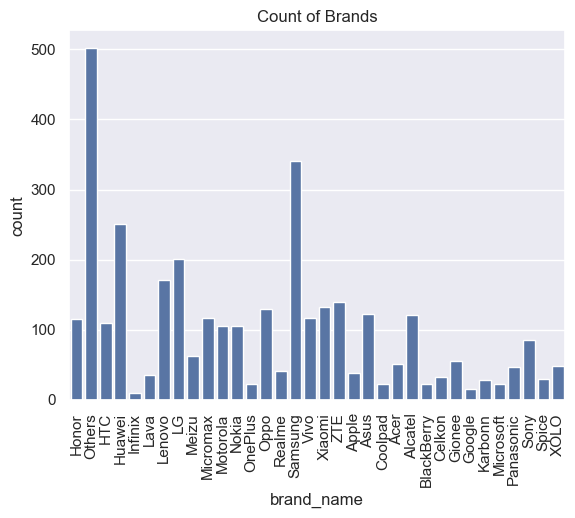

In [12]:
#Starting with a countplot for brands:
sns.countplot(data = df, x = 'brand_name')
plt.xticks(rotation = 90)
plt.title('Count of Brands')
plt.show()

In [13]:
#Show count and % of unique brand names
unique_brands = df['brand_name'].value_counts()
unique_pct = (unique_brands / len(df) * 100).round(2)

unique_summary = pd.DataFrame({
    'Unique Brands': unique_brands,
    'Percentage (%)': unique_pct
})

unique_summary[unique_summary['Unique Brands'] > 0]

,Unique Brands,Percentage (%)
brand_name,,
Others,502,14.530
Samsung,341,9.870
Huawei,251,7.270
LG,201,5.820
Lenovo,171,4.950
ZTE,140,4.050
Xiaomi,132,3.820
Oppo,129,3.730
Asus,122,3.530


**Observations**:

Highest count is for 'Others' at 502 (14.53% of devices).  This is notable because within that category we cannot treat devices as similar brand.

### Operating System

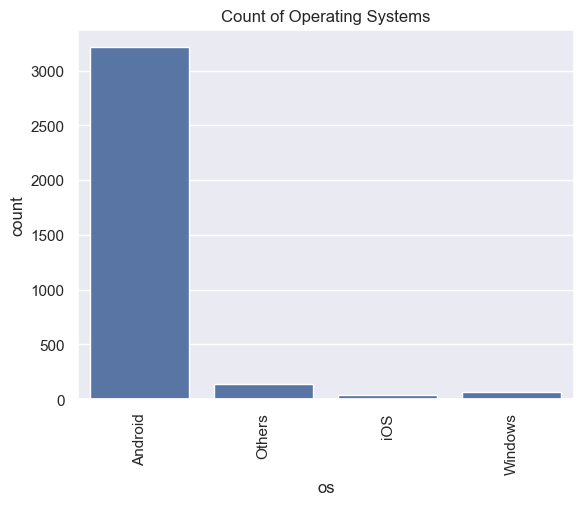

In [14]:
#Doing the same count checks for Operating Systems:
sns.countplot(data = df, x = 'os')
plt.xticks(rotation = 90)
plt.title('Count of Operating Systems')
plt.show()

In [15]:
#Show unique Operating system counts and %s
unique_os = df['os'].value_counts()
os_pct = (unique_os / len(df) * 100).round(2)

os_summary = pd.DataFrame({
    'Unique Operating Systems': unique_os,
    'Percentage (%)': os_pct
})

os_summary[os_summary['Unique Operating Systems'] > 0]

,Unique Operating Systems,Percentage (%)
os,,
Android,3214,93.050
Others,137,3.970
Windows,67,1.940
iOS,36,1.040


**Observations**:

Devices running on Android dominate the data set at 93.05% of all devices.

**Project Question Answered**

2.	What percentage of the used device market is dominated by Android devices?  93.05%

### Screen Size

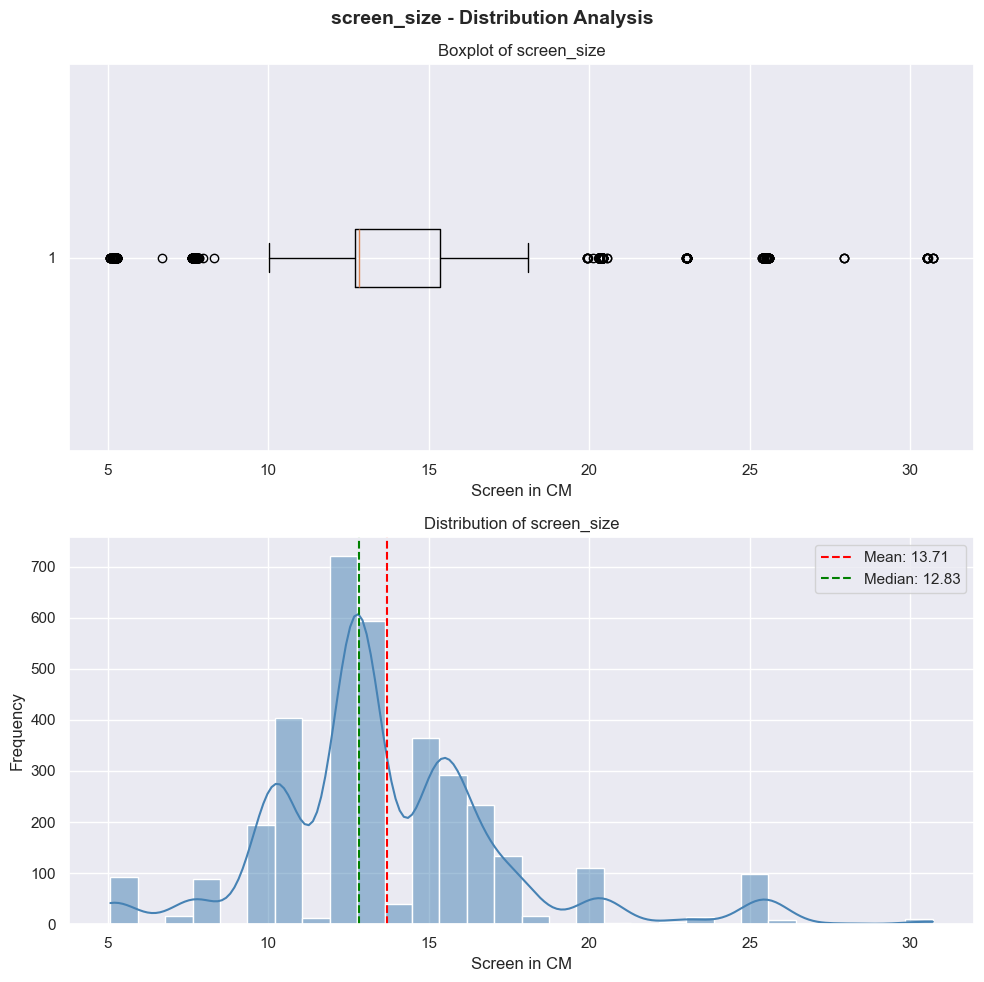

In [16]:
#Box and Histplot of screen sizes
plot_distribution(df, 'screen_size', xlabel='Screen in CM')

In [17]:
describe_distribution(df, 'screen_size')

Lower Outlier Fence = 8.739999999999998
Upper Outlier Fence = 19.3
Outlier count: 450
Skewness:  1.023931801055376
The distribution is highly skewed to the right.


count   3454.000
mean      13.713
std        3.805
min        5.080
25%       12.700
50%       12.830
75%       15.340
max       30.710
Name: screen_size, dtype: float64

**Observations**

The screen size data is highly right skewed.  This is likely due to a large number of small devices (phones) and a small numer of much larger devices (tablets).

While there are many outliers (450), with a min of 5.08 cm (reasonable for a flip phone or basic phone) and a max of 30.71 cm (reasonable for a tablet), the outliers appear to be legitimate data points and do not need to be cleaned.

In [18]:
df[df['screen_size'] > 6]['screen_size'].value_counts().sum()

np.int64(3362)

**Project Question Answered**

5.	Bigger screens are desirable for entertainment purposes as they offer a better viewing experience. How many phones and tablets are available across different brands with a screen size larger than 6 inches? 3362

### 4g Capability

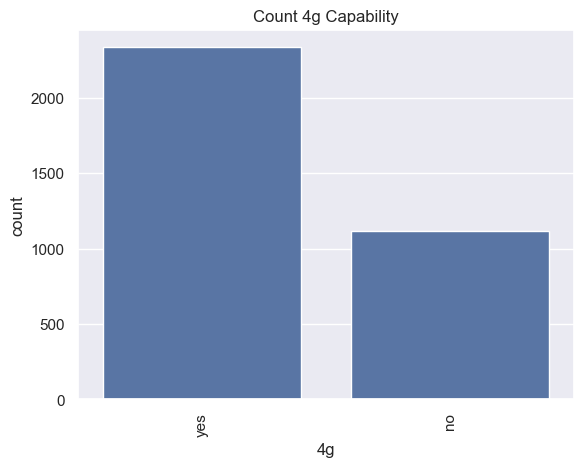

In [19]:
#Count Plot of devices with 4g
sns.countplot(data = df, x = '4g')
plt.xticks(rotation = 90)
plt.title('Count 4g Capability')
plt.show()

In [20]:
#Show 4g count and %
unique_fourg = df['4g'].value_counts()
fourg_pct = (unique_fourg / len(df) * 100).round(2)

fourg_summary = pd.DataFrame({
    '4g Capability': unique_fourg,
    'Percentage (%)': fourg_pct
})

fourg_summary[fourg_summary['4g Capability'] > 0]

,4g Capability,Percentage (%)
4g,,
yes,2335,67.600
no,1119,32.400


**Observations**

67.7% of the devices are 4g capable

### 5g Cabability

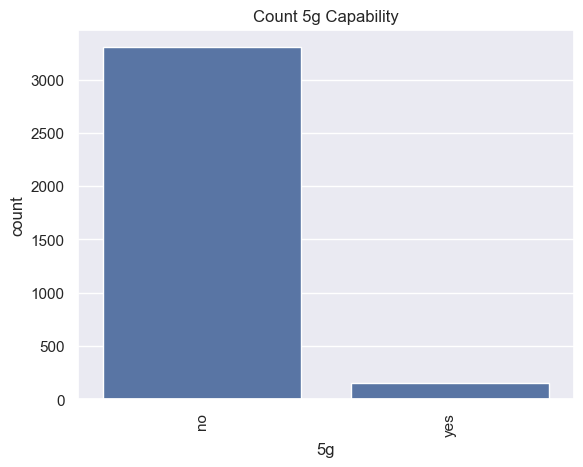

In [21]:
#Count Plot of devices with 5g
sns.countplot(data = df, x = '5g')
plt.xticks(rotation = 90)
plt.title('Count 5g Capability')
plt.show()

In [22]:
#Show 5g count and %
unique_fiveg = df['5g'].value_counts()
fiveg_pct = (unique_fiveg / len(df) * 100).round(2)

fiveg_summary = pd.DataFrame({
    '5g Capability': unique_fiveg,
    'Percentage (%)': fiveg_pct
})

fiveg_summary[fiveg_summary['5g Capability'] > 0]

,5g Capability,Percentage (%)
5g,,
no,3302,95.600
yes,152,4.400


**Observations**

Only 4.4% of the devices are 5g capable.  This highlights a potential limitation of the training data with such a small set to train on for 5g capability compared with 4g capability.

### Main Camera

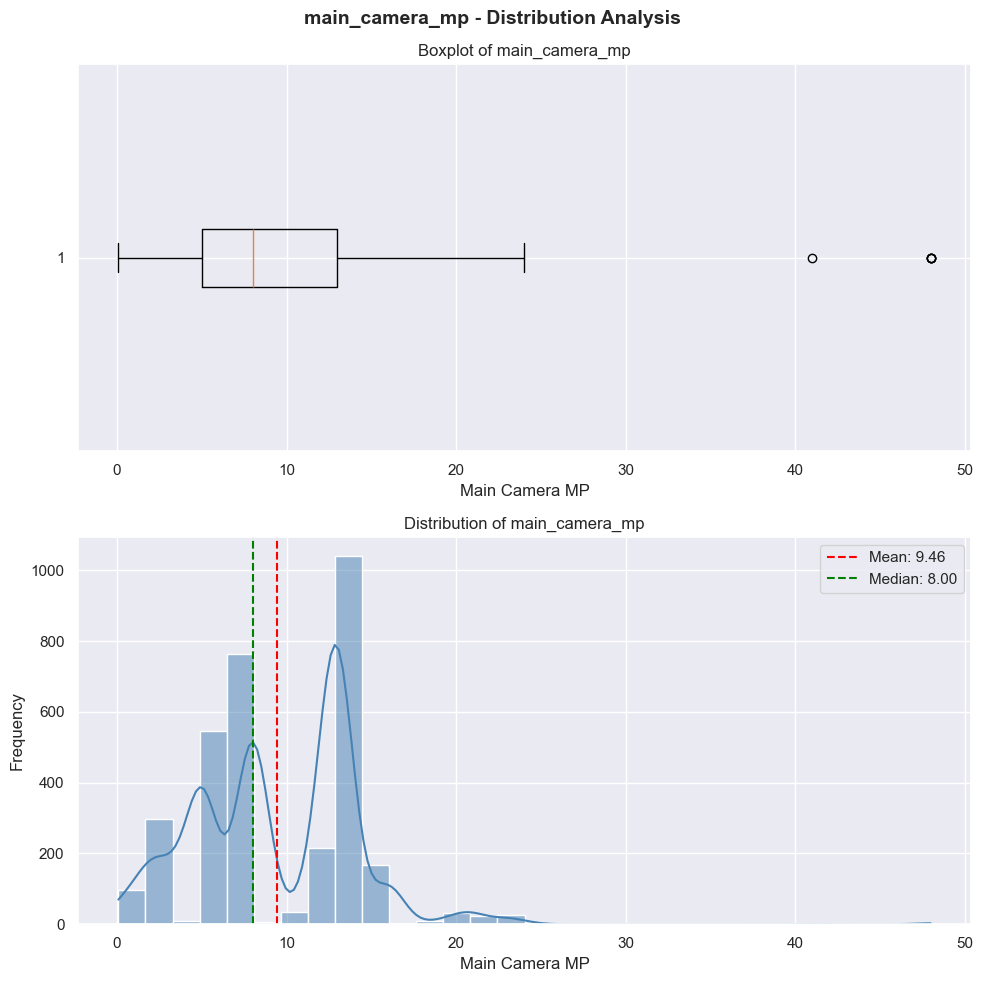

In [23]:
#Displaying distribution of Main Camera MP
plot_distribution(df, 'main_camera_mp', xlabel='Main Camera MP')

In [24]:
describe_distribution(df, 'main_camera_mp')

Lower Outlier Fence = -7.0
Upper Outlier Fence = 25.0
Outlier count: 5
Skewness:  0.7655057967745678
The distribution is moderately skewed to the right.


count   3275.000
mean       9.460
std        4.815
min        0.080
25%        5.000
50%        8.000
75%       13.000
max       48.000
Name: main_camera_mp, dtype: float64

**Observations**

The data is moderately skewed right with some outliers and low values worth looking into.

In [25]:
#Checking the outliers
main_camera_outliers = df[df['main_camera_mp'] > 25]
main_camera_outliers

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
210,ZTE,Android,16.890,yes,no,48.000,16.000,128.000,8.000,5000.000,215.000,2019,336,5.668,6.709
215,ZTE,Android,16.890,yes,no,48.000,16.000,64.000,6.000,5000.000,215.000,2019,506,5.264,6.218
2097,Nokia,Windows,10.290,yes,no,41.000,1.200,32.000,4.000,2000.000,158.000,2013,988,5.105,5.989
3240,Motorola,Android,15.340,yes,no,48.000,25.000,128.000,4.000,3600.000,165.000,2019,371,5.326,5.541
3381,Motorola,Android,15.340,yes,no,48.000,25.000,128.000,4.000,3600.000,165.000,2019,422,5.331,5.541


In [26]:
#Checking the low End
main_camera_low = df[df['main_camera_mp'] < 1]
main_camera_low

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
104,Micromax,Android,7.750,no,no,0.300,0.300,0.500,0.250,1500.000,89.000,2014,956,2.387,3.665
107,Micromax,Android,7.750,no,no,0.300,0.300,16.000,4.000,2000.000,89.000,2013,1029,2.990,3.884
110,Nokia,Android,16.560,yes,no,0.300,8.000,64.000,3.000,4000.000,200.000,2020,310,4.186,5.005
111,Nokia,Android,13.840,yes,no,0.300,5.000,16.000,2.000,3000.000,180.000,2020,193,3.616,4.100
112,Nokia,Android,13.840,yes,no,0.300,5.000,16.000,2.000,3000.000,180.000,2020,356,4.055,4.592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2320,Others,Others,5.180,no,no,0.300,2.000,64.000,0.250,2100.000,150.000,2014,617,2.033,2.937
2324,Others,Others,5.180,no,no,0.300,2.000,32.000,0.250,2100.000,150.000,2014,789,2.323,2.901
2327,Others,Others,7.670,no,no,0.300,2.000,128.000,0.250,2100.000,150.000,2014,555,2.397,3.359
2784,Others,Android,17.780,no,no,0.300,2.000,32.000,4.000,3500.000,354.400,2014,571,4.333,4.388


In [27]:
main_camera_low['main_camera_mp'].value_counts()

main_camera_mp
0.300    69
0.080     1
Name: count, dtype: int64

In [28]:
#Checking the Lowest
main_camera_lowest = df[df['main_camera_mp'] == .08]
main_camera_lowest

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
618,Others,Others,5.180,no,no,0.080,2.000,16.000,4.000,1000.000,80.000,2014,1008,2.630,2.942


**Observations**

First looking at the high end we have 5 outliers.  The highest is 48 megapixels which is in line with current model smart phones and has been available since 2019, so these values appear legitimate and do not need to be treated.  The one suspicious value is the Nokia from 2013, but a quick google search confirms that the Nokia Lumia was released in 2013 with a 41 megapixel camera.  Again, no need to clean.

Next looking at the low values - a minimum of .08 megapixels raises some suspision.  A quick search shows that such devices have been released in the past, but anything in 2014 would have been a button phone, toy, or watch.  Similar results are found for the other low values.  Since we do not have sufficient evidence to say these values are recorded in error, I will  not clean them at this time.

It is important to state here that 179 null values were noted above for this column and will need to be imputed in the preprocessing section of this project.

### Selfie Camera

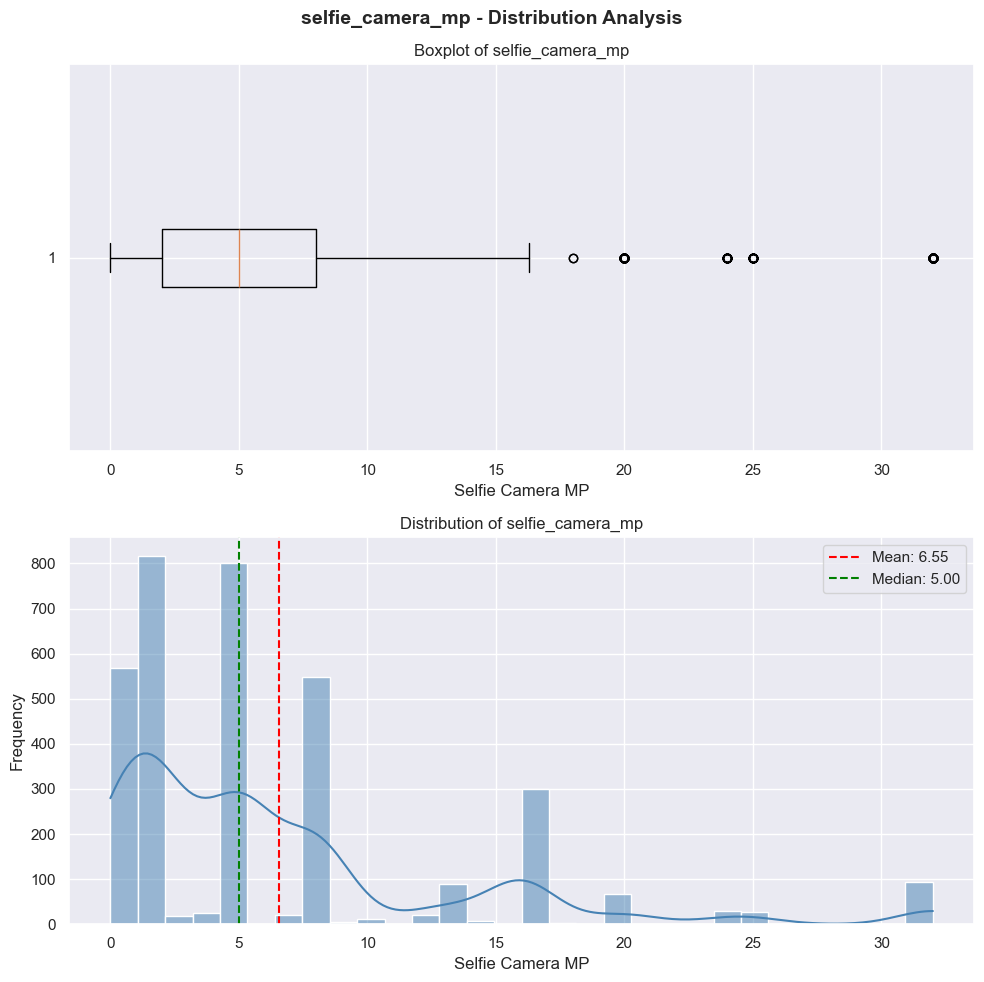

In [29]:
#Displaying distribution of Selfie Camera MP
plot_distribution(df, 'selfie_camera_mp', xlabel='Selfie Camera MP')

In [30]:
describe_distribution(df, 'selfie_camera_mp')

Lower Outlier Fence = -7.0
Upper Outlier Fence = 17.0
Outlier count: 221
Skewness:  1.8016488044775552
The distribution is highly skewed to the right.


count   3452.000
mean       6.554
std        6.970
min        0.000
25%        2.000
50%        5.000
75%        8.000
max       32.000
Name: selfie_camera_mp, dtype: float64

In [31]:
#Checking the max outliers
selfie_camera_outliers = df[df['selfie_camera_mp'] == 32]
selfie_camera_outliers

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
16,Honor,Android,15.900,yes,no,13.000,32.000,128.000,6.000,3750.000,172.000,2019,395,5.022,5.518
41,Huawei,Android,15.900,yes,no,13.000,32.000,64.000,6.000,4000.000,178.000,2019,206,4.997,5.295
47,Huawei,Android,15.900,yes,no,13.000,32.000,128.000,6.000,4000.000,178.000,2019,244,5.143,5.670
52,Huawei,Android,16.230,yes,no,13.000,32.000,128.000,8.000,3500.000,171.000,2019,333,5.428,5.965
53,Huawei,Android,16.230,yes,no,13.000,32.000,128.000,8.000,3500.000,171.000,2019,284,5.379,5.886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3429,Samsung,Android,15.420,yes,no,8.000,32.000,128.000,6.000,4500.000,186.000,2020,213,5.200,5.947
3431,Samsung,Android,15.420,yes,no,12.000,32.000,128.000,6.000,4500.000,179.000,2019,202,5.302,5.634
3432,Samsung,Android,15.370,yes,no,12.000,32.000,64.000,4.000,4000.000,172.000,2019,382,5.069,5.406
3437,Samsung,Android,15.420,yes,yes,12.000,32.000,128.000,6.000,4500.000,206.000,2019,254,5.572,6.742


In [32]:
selfie_camera_outliers['release_year'].value_counts()

release_year
2019    59
2020    35
Name: count, dtype: int64

**Observations**

Selfie Camera resolution is highly right skewed with 221 ourliers.

Taking a look at the maximum outlier of 32 megapixels, there are numerous phones on the market with this feature available in 2019 and 2020.  These values appear to be legitimate and will not be cleaned.

It is important to recall here that 2 null values were noted above and will need to be examined and imputed below.

In [33]:
#Get % of selfie cameras > 8 mp
df[df['selfie_camera_mp'] > 8]['selfie_camera_mp'].value_counts().sum()/df.shape[0]

np.float64(0.18963520555877245)

**Project Question Answered**

6.	A lot of devices nowadays offer great selfie cameras, allowing us to capture our favorite moments with loved ones. What is the distribution of devices offering greater than 8MP selfie cameras across brands?  18.96%

### Internal Memory

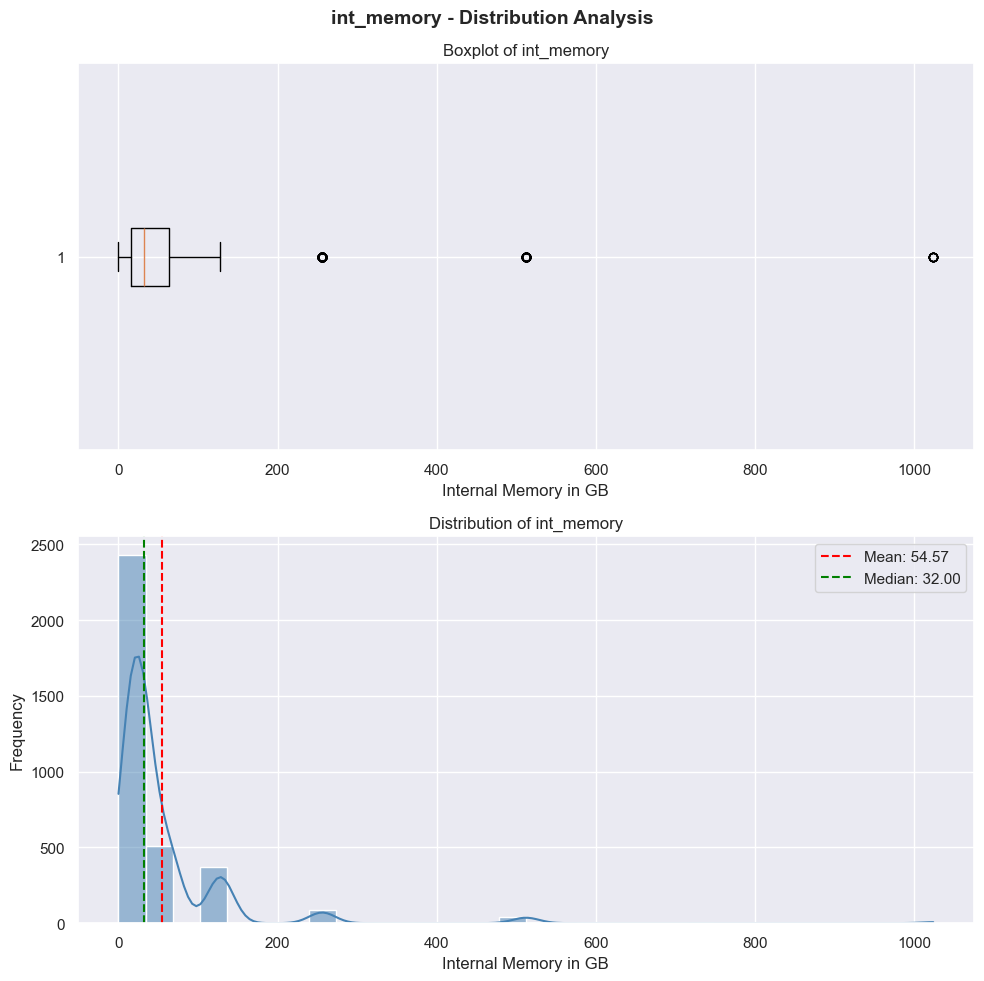

In [34]:
#Displaying distribution of Internal Memory
plot_distribution(df, 'int_memory', xlabel='Internal Memory in GB')

In [35]:
describe_distribution(df, 'int_memory')

Lower Outlier Fence = -56.0
Upper Outlier Fence = 136.0
Outlier count: 138
Skewness:  5.794750005502507
The distribution is highly skewed to the right.


count   3450.000
mean      54.573
std       84.972
min        0.010
25%       16.000
50%       32.000
75%       64.000
max     1024.000
Name: int_memory, dtype: float64

In [36]:
#Checking higher outliers > 500 GB
over_halftb = df[df['int_memory'] > 500]
over_halftb

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
44,Huawei,Android,16.590,yes,yes,13.000,16.000,512.000,12.000,4500.000,198.000,2019,289,5.674,7.438
198,Xiaomi,Android,20.120,yes,yes,12.000,20.000,512.000,12.000,4050.000,241.000,2019,478,6.619,7.823
263,Huawei,Android,16.590,yes,yes,13.000,16.000,512.000,12.000,4500.000,198.000,2019,488,5.996,7.439
516,Alcatel,Others,7.750,no,no,2.000,0.300,512.000,0.250,2820.000,98.000,2015,786,2.863,3.678
558,Alcatel,Android,7.750,no,no,2.000,0.300,512.000,0.250,1300.000,118.000,2013,858,2.843,3.935
565,Alcatel,Android,7.750,no,no,2.000,0.300,512.000,0.250,1400.000,118.000,2013,911,3.640,4.602
631,Others,Android,7.750,no,no,2.000,0.300,512.000,0.250,1500.000,122.700,2013,977,3.315,4.249
644,Apple,iOS,30.710,yes,no,12.000,7.000,1024.000,4.000,9720.000,631.000,2018,543,5.808,7.004
645,Apple,iOS,27.940,yes,no,12.000,7.000,1024.000,4.000,7812.000,468.000,2018,525,6.159,6.779
772,Asus,Android,12.700,no,no,8.000,0.300,1024.000,4.000,2500.000,160.000,2014,860,3.523,4.594


**Observations**

Internal memory is highly right skewed with 138 outliers on the high end.

Pulling the devices with >500 GB internal memory, we see quite a few with large memory and very small screens which sets off alarm bells.  It is extremely likely that either the screen size or the internal memory values are incorrect.  

It is also possible that the data was input in inches whereas the above information states measurements are in CM and that some information did not fit the table.  For example: (from a google search for one of these devices) "The ASUS ZenBook Pro 14 Duo OLED (UX8402) (such as model UX8402ZA-DB76T) fits this description, featuring a main 14.5-inch screen and a 12.7-inch 2.8K 120Hz secondary touchscreen (ScreenPad Plus). It includes 1TB M.2 NVMe PCIe 4.0 SSD storage, 32GB RAM, and an Intel Core i9 processor."  Still not all of these specs match the device I was searching for.

For the sake of this project we will continue without cleaning this data.  However, in a real world project I would question the quality of this data and consider significantly trimming the data or requesting an entirely new data set to model off of.

It is important to recall here that 4 null values were noted above and will need to be examined and imputed below.

### RAM

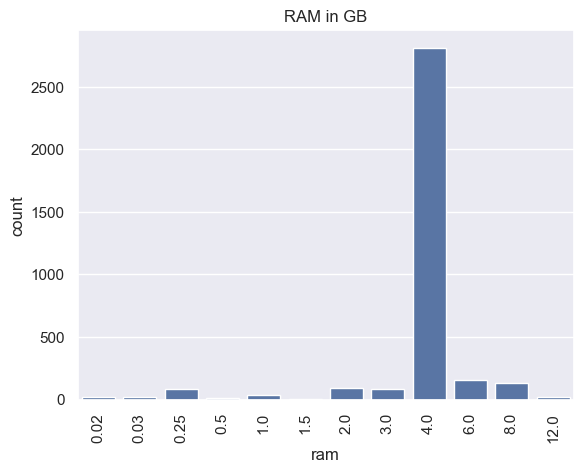

In [37]:
#Count Plot of RAM
sns.countplot(data = df, x = 'ram')
plt.xticks(rotation = 90)
plt.title('RAM in GB')
plt.show()

In [38]:
#Show RAM count and %
unique_ram = df['ram'].value_counts()
ram_pct = (unique_ram / len(df) * 100).round(2)

ram_summary = pd.DataFrame({
    'RAM': unique_ram,
    'Percentage (%)': ram_pct
})

ram_summary[ram_summary['RAM'] > 0]

,RAM,Percentage (%)
ram,,
4.000,2815,81.500
6.000,154,4.460
8.000,130,3.760
2.000,90,2.610
0.250,83,2.400
3.000,81,2.350
1.000,34,0.980
12.000,18,0.520
0.020,18,0.520


In [39]:
low_ram = df[df['ram'] < 1]
low_ram['screen_size'].value_counts().sort_index(ascending=False)

screen_size
20.320     1
17.780     1
12.700     2
11.760     2
10.340     1
10.290     2
10.160    18
10.080     1
10.030     2
7.850      1
7.750     26
7.670      2
7.620      9
5.280     15
5.230      5
5.180     34
5.130      2
5.080      3
Name: count, dtype: int64

**Observations**

The majority of devices (81.5%) have 4GB RAM.

While some of the RAM values are very small, they are not outside of what is possible for devices of the size.

It is important to recall here that we noted 4 null RAM values above that will need to be imputed below in the Preprocessing section.

### Battery

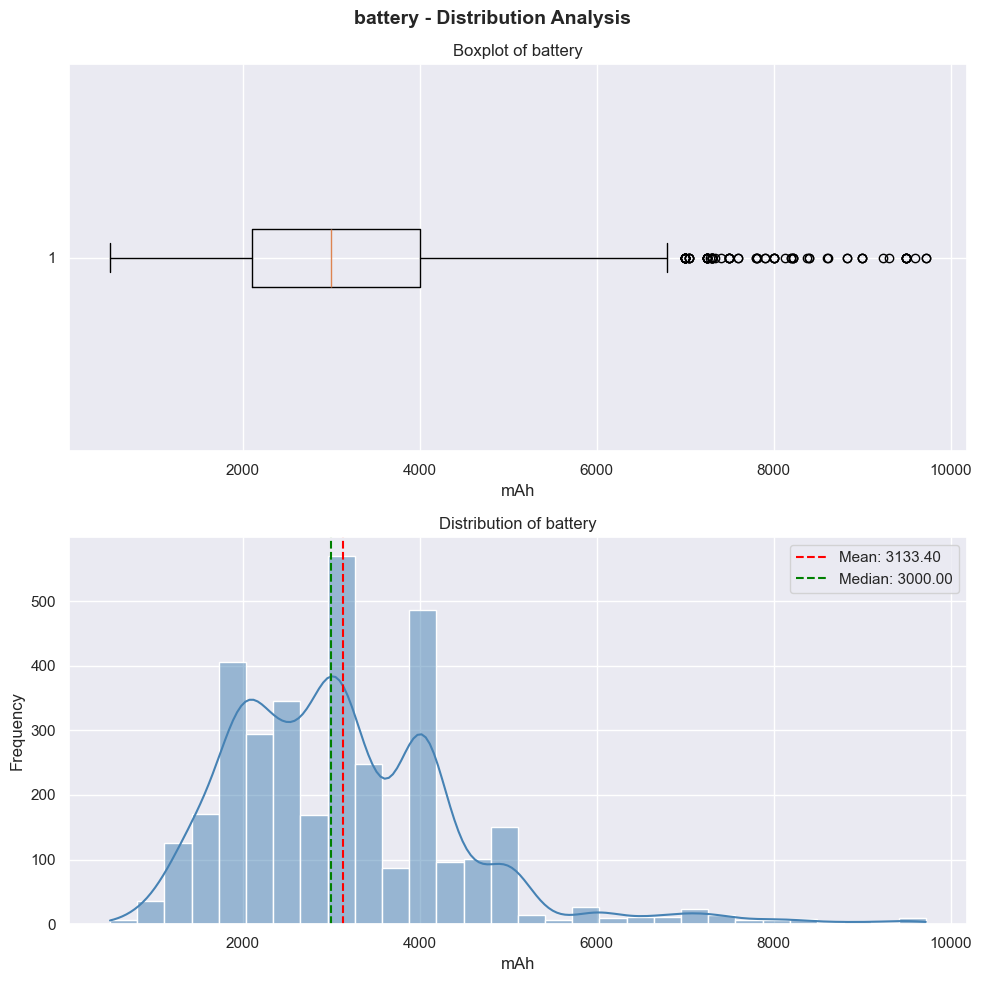

In [40]:
#Distribution of Battery Capacity in mAh
plot_distribution(df, 'battery', 'mAh')

In [41]:
describe_distribution(df, 'battery')

Lower Outlier Fence = -750.0
Upper Outlier Fence = 6850.0
Outlier count: 77
Skewness:  1.332269994146739
The distribution is highly skewed to the right.


count   3448.000
mean    3133.403
std     1299.683
min      500.000
25%     2100.000
50%     3000.000
75%     4000.000
max     9720.000
Name: battery, dtype: float64

**Observations**

Battery capacity is highly right skewed with 77 outliers to the right.

The minimum value of 500 mAh stands out as unusually low.

In [42]:
battery_low = df[df['battery'] < 750]
battery_low

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
898,Others,Others,5.080,no,no,1.300,0.300,64.000,0.250,620.000,69.000,2013,990,2.236,3.007
3064,ZTE,Android,10.190,yes,no,5.000,8.000,32.000,4.000,500.000,165.000,2019,383,4.799,6.109


**Observations**

500 mAh is extremely low for a device released in 2019 with the above specifications.  A google search returns a similar device with 5,000 mAh.  I will replace this value with null and impute below.

In [43]:
#Replace likely error with NaN to impute in preprocessing
df.loc[df['battery'] < 501, 'battery'] = np.nan

In [44]:
#Check that value is replaced
df[df['battery'].isnull()]

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
1829,Meizu,Android,12.830,yes,no,13.000,5.000,16.000,4.000,NaN,145.000,2014,986,4.178,4.864
1831,Meizu,Android,12.830,yes,no,20.700,5.000,16.000,4.000,NaN,158.000,2014,1043,4.879,5.991
1832,Meizu,Android,13.610,yes,no,20.700,2.000,16.000,4.000,NaN,147.000,2014,1007,4.742,5.826
1962,Microsoft,Windows,25.550,no,no,5.000,3.500,32.000,4.000,NaN,675.900,2013,931,5.231,5.803
2058,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.020,NaN,81.000,2016,815,2.719,3.375
2059,Nokia,Others,5.180,no,no,0.300,0.000,0.060,NaN,NaN,82.600,2016,1023,2.765,3.658
3064,ZTE,Android,10.190,yes,no,5.000,8.000,32.000,4.000,NaN,165.000,2019,383,4.799,6.109


**Observations**

We now have 7 null battery values to deal with in preprocessing

### Weight

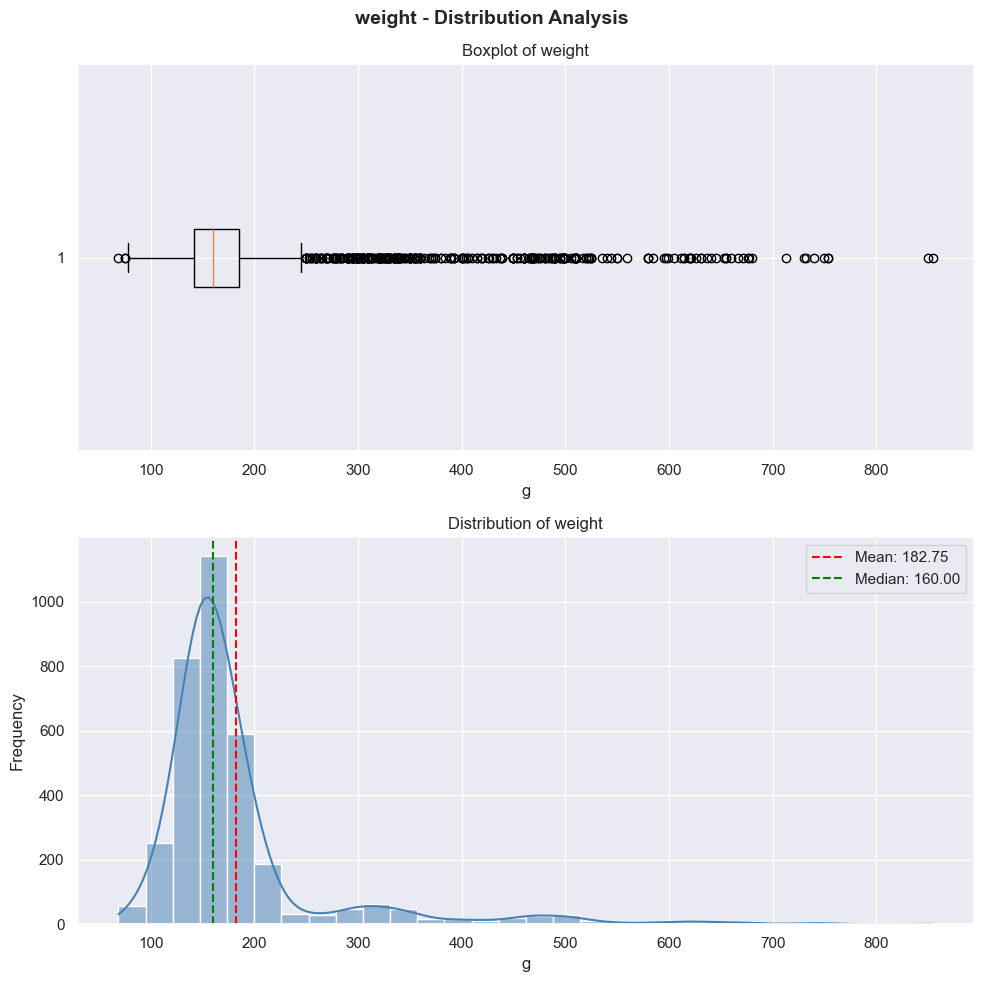

In [45]:
#Distribution of Weight
plot_distribution(df, 'weight', 'g')

In [46]:
describe_distribution(df, 'weight')

Lower Outlier Fence = 77.5
Upper Outlier Fence = 249.5
Outlier count: 368
Skewness:  3.2324980211208714
The distribution is highly skewed to the right.


count   3447.000
mean     182.752
std       88.413
min       69.000
25%      142.000
50%      160.000
75%      185.000
max      855.000
Name: weight, dtype: float64

In [47]:
#Check low weight against size for sanity check
low_weight = df[df['weight'] < 100]
low_weight['screen_size'].value_counts().sort_index(ascending = False)

screen_size
10.360     6
10.340     1
10.290     3
10.240     1
10.160     6
10.030     2
7.750      7
7.620      2
5.280     10
5.180     32
5.130      2
5.080      4
Name: count, dtype: int64

**Observations**

The data is highly skewed right with 368 outliers to the right.

The outliers are not unusual for larger devices like tablets.

The minimum is quite small, but not impossible for a small device.

It is important to recall here that we noted 7 null values above that will need to be revisited and imputed below in preprocessing.

### Release Year

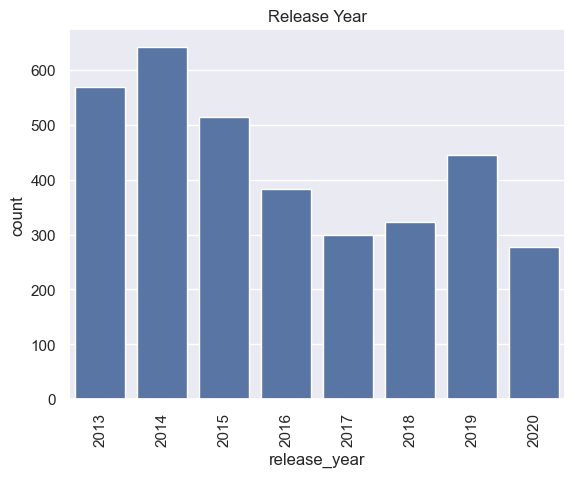

In [48]:
#Count Plot of Release Years
sns.countplot(data = df, x = 'release_year')
plt.xticks(rotation = 90)
plt.title('Release Year')
plt.show()

In [49]:
#Show Release Year count and %
unique_year = df['release_year'].value_counts()
year_pct = (unique_year / len(df) * 100).round(2)

year_summary = pd.DataFrame({
    'Year': unique_year,
    'Percentage (%)': year_pct
})

year_summary[year_summary['Year'] > 0]

,Year,Percentage (%)
release_year,,
2014,642,18.590
2013,570,16.500
2015,515,14.910
2019,446,12.910
2016,383,11.090
2018,322,9.320
2017,299,8.660
2020,277,8.020


**Observations**

Half of the devices are 2013-2015 releases.

The other Half are 2016-2020 releases.

### Days Used

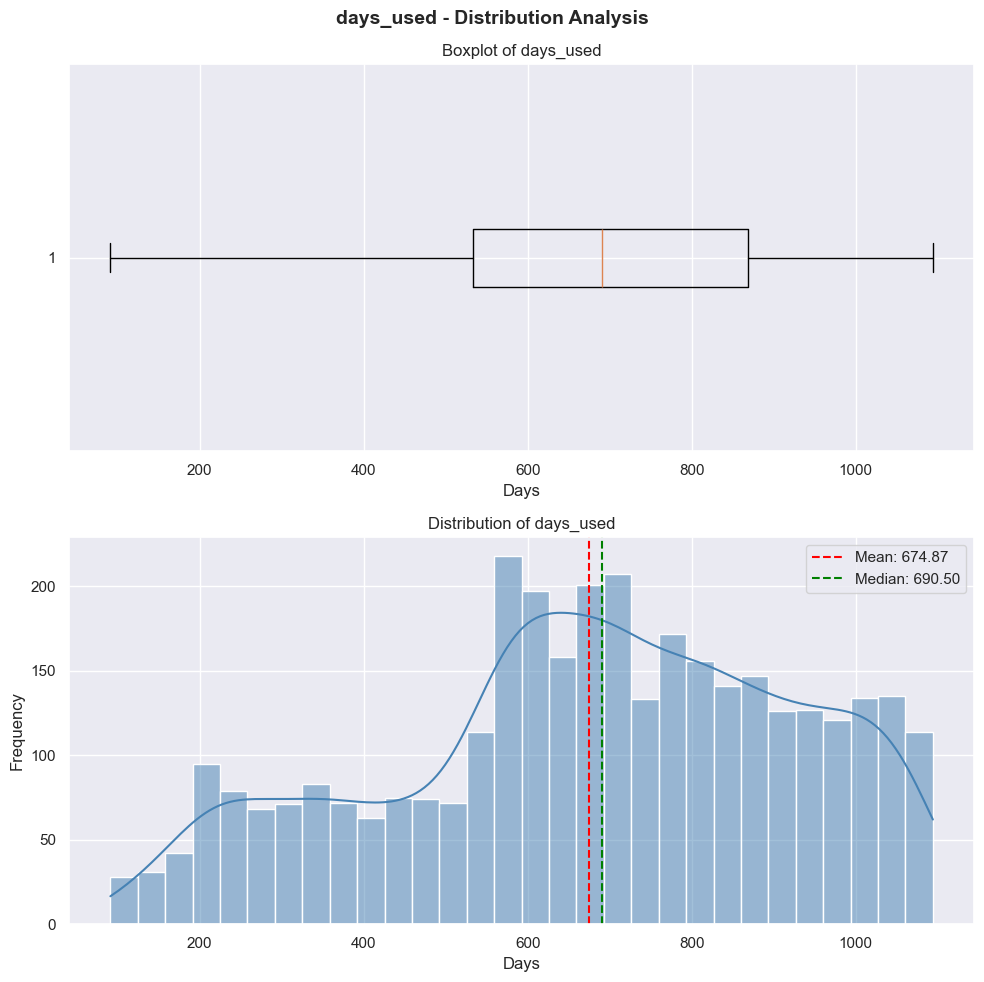

In [50]:
#Histplot and Boxplot of distribution of days used
plot_distribution(df, 'days_used', 'Days')

In [51]:
describe_distribution(df, 'days_used')

Lower Outlier Fence = 30.625
Upper Outlier Fence = 1371.625
Outlier count: 0
Skewness:  -0.34397722518149887
The distribution is approximately symmetric.


count   3454.000
mean     674.870
std      248.580
min       91.000
25%      533.500
50%      690.500
75%      868.750
max     1094.000
Name: days_used, dtype: float64

**Observations**

The days used data is approximately symmetric with no outliers or unusual values.

### Normalized Used Price

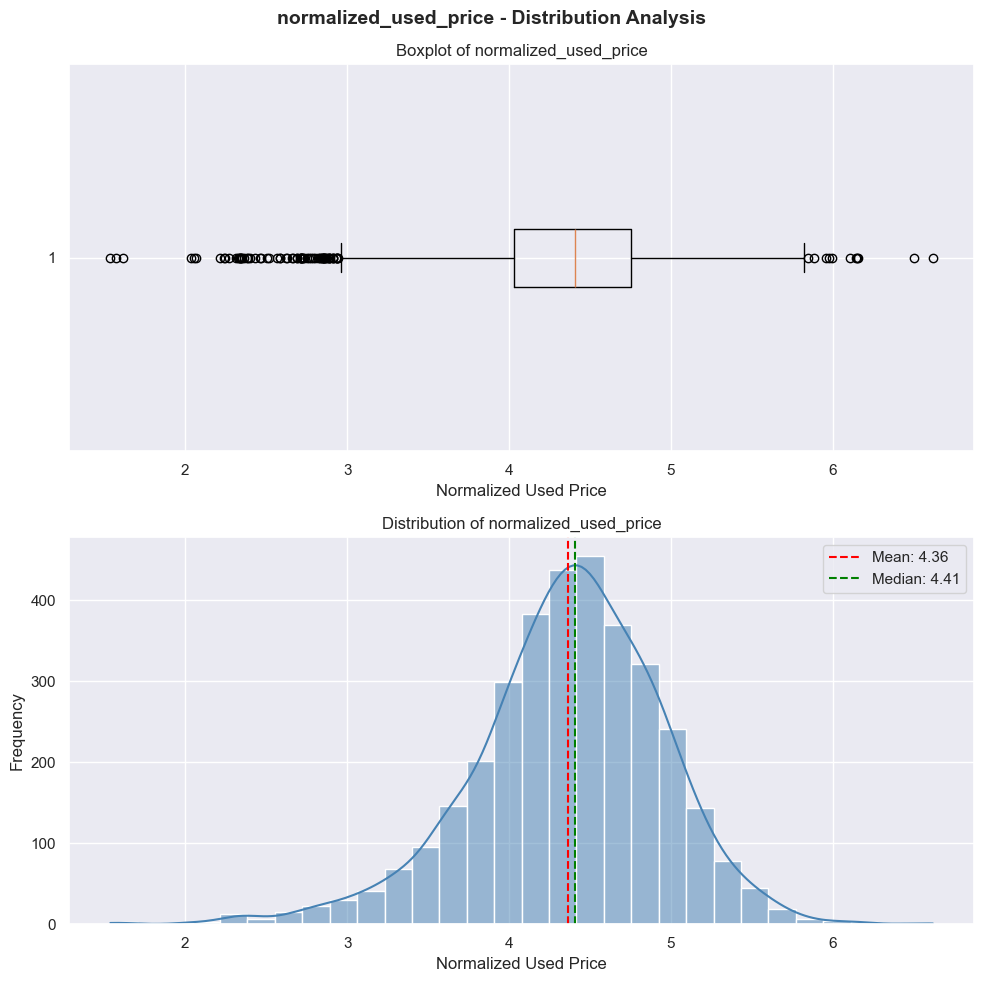

In [52]:
#Normalized used price distribution
plot_distribution(df, 'normalized_used_price', 'Normalized Used Price')

In [53]:
describe_distribution(df, 'normalized_used_price')

Lower Outlier Fence = 2.9512771200935473
Upper Outlier Fence = 5.838353740438841
Outlier count: 85
Skewness:  -0.5323378174955729
The distribution is moderately skewed to the left.


count   3454.000
mean       4.365
std        0.589
min        1.537
25%        4.034
50%        4.405
75%        4.756
max        6.619
Name: normalized_used_price, dtype: float64

**Observations** & **Project Question Answered**

1.	What does the distribution of normalized used device prices look like?

The distribution is moderately skewed left with 85 outliers (both left and right).  However, since the prices are already normalized it would be hard to say if any are unusual or need to be treated.

### Normalized New Price

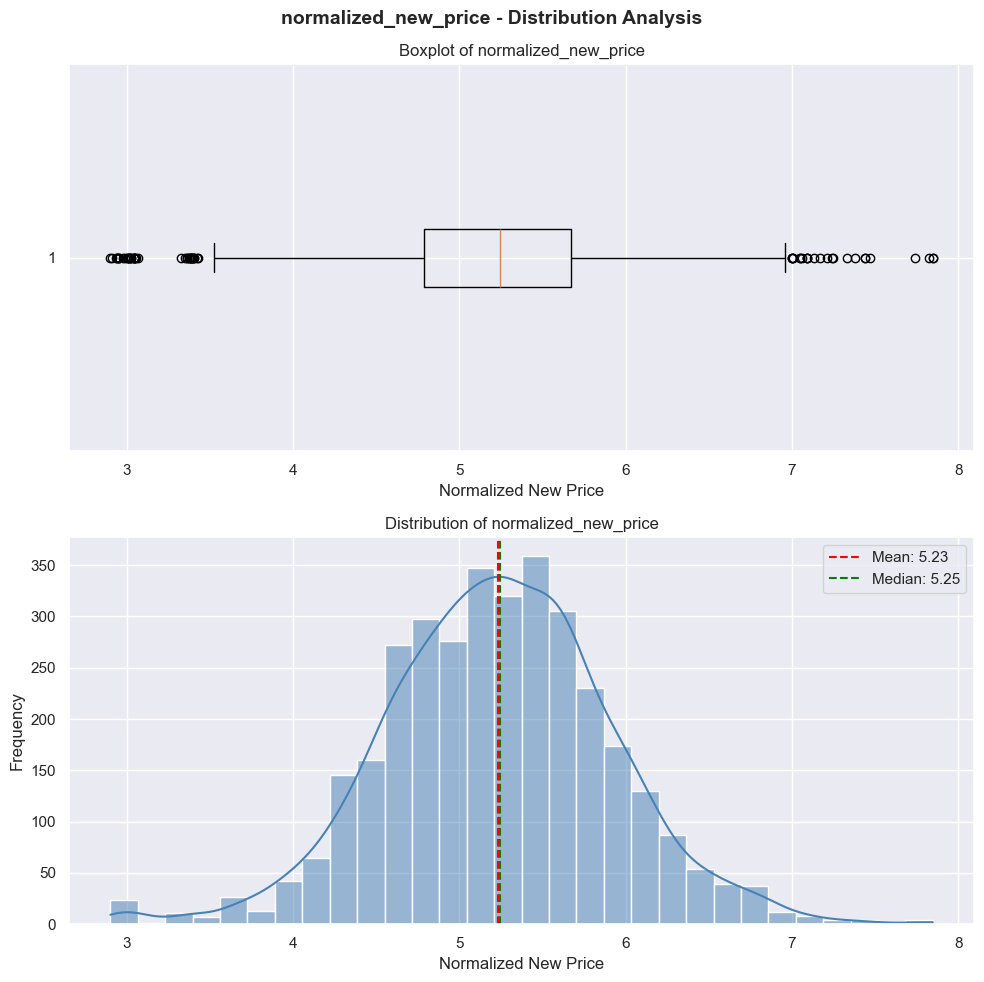

In [54]:
#Normalized new price distribution
plot_distribution(df, 'normalized_new_price', 'Normalized New Price')

In [55]:
describe_distribution(df, 'normalized_new_price')

Lower Outlier Fence = 3.4652772332346267
Upper Outlier Fence = 6.998782860346086
Outlier count: 66
Skewness:  -0.07702603975081772
The distribution is approximately symmetric.


count   3454.000
mean       5.233
std        0.684
min        2.901
25%        4.790
50%        5.246
75%        5.674
max        7.848
Name: normalized_new_price, dtype: float64

**Observations**

The normalized new price is approximately symmetric with 66 outliers.  Since the prices are already normalized it would be hard to say if any are unusual or need to be treated.

## Data Preprocessing

- Missing value treatment
- Feature engineering (if needed)

In [56]:
#First let's revisit our null values as we have added one

# Show null counts and percentage of total rows
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)

null_summary = pd.DataFrame({
    'Missing Values': null_counts,
    'Percentage (%)': null_pct
})

null_summary[null_summary['Missing Values'] > 0]

,Missing Values,Percentage (%)
main_camera_mp,179,5.180
selfie_camera_mp,2,0.060
int_memory,4,0.120
ram,4,0.120
battery,7,0.200
weight,7,0.200


### Investigating Main Camera Null Values



In [57]:
# Check if missing camera values relate to older release years
print(df[df['main_camera_mp'].isnull()]['release_year'].value_counts().sort_index())

release_year
2017      2
2018     10
2019     45
2020    122
Name: count, dtype: int64


In [58]:
#Display main_camera_mp null values
main_camera_null = df[df['main_camera_mp'].isnull()]
main_camera_null

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
59,Infinix,Android,17.320,yes,no,NaN,8.000,32.000,2.000,6000.000,209.000,2020,245,4.282,4.598
60,Infinix,Android,15.390,yes,no,NaN,8.000,64.000,4.000,5000.000,185.000,2020,173,4.364,4.712
61,Infinix,Android,15.390,yes,no,NaN,8.000,32.000,2.000,5000.000,185.000,2020,256,4.181,4.505
62,Infinix,Android,15.390,yes,no,NaN,16.000,32.000,3.000,4000.000,178.000,2019,316,4.555,4.602
63,Infinix,Android,15.290,yes,no,NaN,16.000,32.000,2.000,4000.000,165.000,2019,468,4.417,4.871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3411,Realme,Android,15.340,yes,no,NaN,16.000,64.000,4.000,4000.000,183.000,2019,503,4.570,5.160
3412,Realme,Android,15.320,yes,no,NaN,16.000,64.000,4.000,4035.000,184.000,2019,433,4.521,5.074
3413,Realme,Android,15.320,yes,no,NaN,25.000,64.000,4.000,4045.000,172.000,2019,288,4.778,4.967
3448,Asus,Android,16.740,yes,no,NaN,24.000,128.000,8.000,6000.000,240.000,2019,325,5.715,7.059


Observations:

Judging by the brand names, the screen sizes, the existence of a selfie camera, and a quick google search of these brands it appears unlikely that these devices do not have a camera

We will treat these as missing entries and impute with either the mean or median value for the given brands depending on distribution.

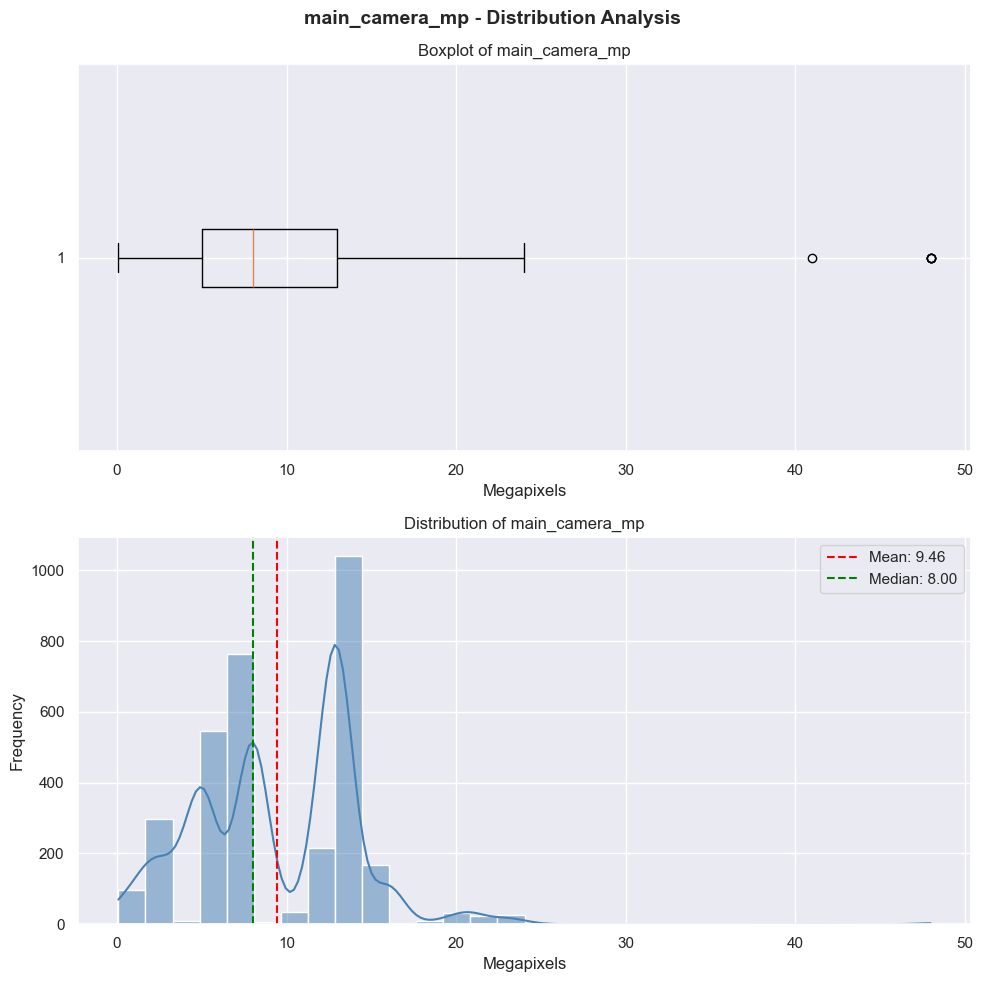

In [59]:
#Check distribution with a stacked boxplot and histplot
plot_distribution(df, 'main_camera_mp', xlabel='Megapixels')

In [60]:
#Describing the graphs:
describe_distribution(df, 'main_camera_mp')

Lower Outlier Fence = -7.0
Upper Outlier Fence = 25.0
Outlier count: 5
Skewness:  0.7655057967745678
The distribution is moderately skewed to the right.


count   3275.000
mean       9.460
std        4.815
min        0.080
25%        5.000
50%        8.000
75%       13.000
max       48.000
Name: main_camera_mp, dtype: float64

**Observations**:

The lower fence is negative, which is impossible for this feature. No lower outliers exist by definition. The 5 outliers are all on the upper end.

Since the data is right skewed I will impute the null values with the median value for main_camera_mp.

In [61]:
#Imputing null values in main_camera_mp column with the median value:
df['main_camera_mp'] = df['main_camera_mp'].fillna(df['main_camera_mp'].median())

#Check that imputation worked:
print(df['main_camera_mp'].isnull().sum())

0


### Investigating Selfie Camera Null Values


In [62]:
#Display selfie_camera_mp null values
selfie_camera_null = df[df['selfie_camera_mp'].isnull()]
selfie_camera_null

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
1080,Google,Android,15.320,yes,no,12.200,NaN,64.000,4.000,3430.000,184.000,2018,475,5.574,6.866
1081,Google,Android,12.830,yes,no,12.200,NaN,64.000,4.000,2915.000,148.000,2018,424,4.465,6.745


**Observations**:

The 2 null selfie camera values are both Google devices from 2018 with some similar features.

In [63]:
#selfie_camera unique values
df['selfie_camera_mp'].unique()

array([ 5.  , 16.  ,  8.  , 32.  ,  2.  ,  0.3 , 13.  , 14.5 , 24.  ,
       10.  ,  1.3 , 20.  , 25.  ,  0.  , 12.  ,  7.  ,  1.2 ,  3.  ,
        2.1 ,  1.  ,  4.  ,  1.1 ,   nan, 10.5 ,  1.6 ,  1.8 ,  3.5 ,
        0.9 ,  1.25, 18.  ,  1.9 ,  9.  ,  3.7 , 16.3 ,  5.1 ,  2.2 ,
       14.  ,  0.65])

**Observations**:

We see that both 0 and NaN are unique values for selfie_camera.

In [64]:
#Display selfie_camera rows with value of 0 or nan
df[(df['selfie_camera_mp'] == 0) | (df['selfie_camera_mp'].isnull())]

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
113,Nokia,Others,5.180,no,no,0.300,0.000,0.100,0.030,1020.000,90.500,2020,272,2.910,3.400
114,Nokia,Others,5.180,no,no,0.300,0.000,0.060,NaN,1020.000,91.300,2020,288,2.729,2.911
116,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.020,1200.000,88.200,2020,266,3.371,3.699
117,Nokia,Others,5.180,yes,no,0.300,0.000,NaN,0.020,1200.000,86.500,2019,234,2.721,3.688
332,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.030,1020.000,90.500,2020,322,2.519,3.386
333,Nokia,Others,5.180,no,no,0.300,0.000,0.100,0.030,1020.000,91.300,2020,148,2.565,3.012
335,Nokia,Others,5.180,no,no,0.300,0.000,0.100,NaN,1200.000,88.200,2020,327,3.063,3.689
336,Nokia,Others,5.180,yes,no,0.300,0.000,0.100,0.030,1200.000,86.500,2019,414,2.789,3.685
1080,Google,Android,15.320,yes,no,12.200,NaN,64.000,4.000,3430.000,184.000,2018,475,5.574,6.866
1081,Google,Android,12.830,yes,no,12.200,NaN,64.000,4.000,2915.000,148.000,2018,424,4.465,6.745


**Observations**:

We see all 0 values for selfie_camera_mp are Nokia phones with very little ram or internal memory.  These may be flip phones with only one camera.  Whatever the case, the data is consistent.  The 2 NAN values are for a google phone implying that these are missing data entries.

Conclusion: Zero values represent devices without a front-facing camera (confirmed by device characteristics). NaN values represent missing data entries. These are fundamentally different and must be treated differently — zeros are valid data, NaNs require imputation.

In [65]:
#Filtering devices missing selfie camera data on their common attributes
filtered_selfie = df[(df['brand_name'] == 'Google') & (df['os'] == 'Android') & (df['4g'] == 'yes') & (df['5g'] == 'no') & (df['main_camera_mp'] == 12.200) & (df['int_memory'] == 64.000) & (df['ram'] == 4.000)]
filtered_selfie

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
1080,Google,Android,15.320,yes,no,12.200,NaN,64.000,4.000,3430.000,184.000,2018,475,5.574,6.866
1081,Google,Android,12.830,yes,no,12.200,NaN,64.000,4.000,2915.000,148.000,2018,424,4.465,6.745
1082,Google,Android,12.700,yes,no,12.200,8.000,64.000,4.000,2700.000,143.000,2017,890,4.825,6.311
1083,Google,Android,15.240,yes,no,12.200,8.000,64.000,4.000,3520.000,175.000,2017,554,5.248,6.272
3189,Google,Android,15.240,yes,no,12.200,8.000,64.000,4.000,3700.000,167.000,2019,318,4.878,5.693
3190,Google,Android,12.850,yes,no,12.200,8.000,64.000,4.000,3000.000,147.000,2019,508,4.471,5.538
3330,Google,Android,15.240,yes,no,12.200,8.000,64.000,4.000,3700.000,167.000,2019,397,4.778,5.693
3331,Google,Android,12.850,yes,no,12.200,8.000,64.000,4.000,3000.000,147.000,2019,186,4.745,5.538


**Observations**:

If we filter on all of the like attributes shared by these 2 rows except release_year we see that the models from 2017 and 2019 both had 8.000 mp cameras.  It seems reasonable to assume the 2018 model also had an 8.00 mp selfie camera and this was just a miss in data entry.

I will impute the 2 missing values with 8.000 to match similar models from the year before and after.

In [66]:
#Impute selfie camera values:
df['selfie_camera_mp'] = df['selfie_camera_mp'].fillna(8.000)

#Check that imputation worked:
print(df['selfie_camera_mp'].isnull().sum())

0


### Investigating Internal Memory Null Values

In [67]:
#Display int_memory null values
int_memory_null = df[df['int_memory'].isnull()]
int_memory_null

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
117,Nokia,Others,5.180,yes,no,0.300,0.000,NaN,0.020,1200.000,86.500,2019,234,2.721,3.688
2035,Nokia,Others,5.180,no,no,5.000,0.000,NaN,0.030,1020.000,157.000,2019,501,2.344,3.420
2064,Nokia,Others,5.180,no,no,0.300,0.000,NaN,0.020,1100.000,78.400,2015,559,2.587,3.379
2092,Nokia,Others,7.620,no,no,5.000,0.000,NaN,0.020,1010.000,100.000,2013,1043,3.536,4.371


**Observations**:

All four missing internal memory entries are Nokias

All are running on 'other' operating system

3/4 have 5.180 screen size

3/4 lack 4g

All lack 5g

All lack a selfie camera

All have very low ram

2/4 were released > 10 years ago

In [68]:
#Filtering devices Internal Memory data on their common attributes
filtered_int_memory = df[(df['brand_name'] == 'Nokia') & (df['os'] == 'Others') & (df['5g'] == 'no') & (df['selfie_camera_mp'] == 0.000) & (df['ram'] < 0.4000)]
filtered_int_memory

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
113,Nokia,Others,5.180,no,no,0.300,0.000,0.100,0.030,1020.000,90.500,2020,272,2.910,3.400
116,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.020,1200.000,88.200,2020,266,3.371,3.699
117,Nokia,Others,5.180,yes,no,0.300,0.000,NaN,0.020,1200.000,86.500,2019,234,2.721,3.688
332,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.030,1020.000,90.500,2020,322,2.519,3.386
333,Nokia,Others,5.180,no,no,0.300,0.000,0.100,0.030,1020.000,91.300,2020,148,2.565,3.012
336,Nokia,Others,5.180,yes,no,0.300,0.000,0.100,0.030,1200.000,86.500,2019,414,2.789,3.685
2035,Nokia,Others,5.180,no,no,5.000,0.000,NaN,0.030,1020.000,157.000,2019,501,2.344,3.420
2044,Nokia,Others,5.180,yes,no,2.000,0.000,0.100,0.020,1100.000,117.000,2018,417,3.916,4.506
2049,Nokia,Others,5.180,yes,no,2.000,0.000,0.060,0.020,1200.000,88.100,2018,582,3.560,4.611
2052,Nokia,Others,5.180,no,no,2.000,0.000,0.100,0.020,1200.000,88.200,2017,680,3.603,4.257


In [69]:
filtered_int_memory['int_memory'].unique()

array([0.1 , 0.06,  nan])

**Observations**:

Filtering the dataset by the attributes that are common to all null internal value rows, we see that there are only 2 non-null values: 0.1 and 0.06.

In [70]:
#Filtering further to find commonalities in int_memory
filtered_int_memory_pointone = df[(df['brand_name'] == 'Nokia') & (df['os'] == 'Others') & (df['5g'] == 'no') & (df['selfie_camera_mp'] == 0.000) & (df['ram'] < 0.4000) & (df['int_memory'] == 0.100)]
filtered_int_memory_pointone

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
113,Nokia,Others,5.180,no,no,0.300,0.000,0.100,0.030,1020.000,90.500,2020,272,2.910,3.400
333,Nokia,Others,5.180,no,no,0.300,0.000,0.100,0.030,1020.000,91.300,2020,148,2.565,3.012
336,Nokia,Others,5.180,yes,no,0.300,0.000,0.100,0.030,1200.000,86.500,2019,414,2.789,3.685
2044,Nokia,Others,5.180,yes,no,2.000,0.000,0.100,0.020,1100.000,117.000,2018,417,3.916,4.506
2052,Nokia,Others,5.180,no,no,2.000,0.000,0.100,0.020,1200.000,88.200,2017,680,3.603,4.257
2057,Nokia,Others,5.180,no,no,2.000,0.000,0.100,0.020,1000.000,160.000,2017,554,3.773,4.099
2062,Nokia,Others,5.180,no,no,2.000,0.000,0.100,0.020,1100.000,79.000,2015,1012,3.200,3.736
2074,Nokia,Others,5.280,no,no,2.000,0.000,0.100,0.020,1200.000,99.800,2014,631,3.367,3.914
2075,Nokia,Others,5.280,no,no,2.000,0.000,0.100,0.030,1200.000,100.600,2014,654,3.374,3.933
2084,Nokia,Others,5.180,no,no,2.000,0.000,0.100,0.020,1830.000,83.600,2014,565,3.072,3.712


In [71]:
#Filtering further to find commonalities in int_memory
filtered_int_memory_pointosix = df[(df['brand_name'] == 'Nokia') & (df['os'] == 'Others') & (df['5g'] == 'no') & (df['selfie_camera_mp'] == 0.000) & (df['ram'] < 0.4000) & (df['int_memory'] == 0.060)]
filtered_int_memory_pointosix

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
116,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.020,1200.000,88.200,2020,266,3.371,3.699
332,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.030,1020.000,90.500,2020,322,2.519,3.386
2049,Nokia,Others,5.180,yes,no,2.000,0.000,0.060,0.020,1200.000,88.100,2018,582,3.560,4.611
2058,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.020,NaN,81.000,2016,815,2.719,3.375
2060,Nokia,Others,5.280,no,no,2.000,0.000,0.060,0.020,1200.000,91.800,2015,867,2.935,4.220
2061,Nokia,Others,5.280,no,no,2.000,0.000,0.060,0.030,1200.000,91.800,2015,772,3.285,4.248
2063,Nokia,Others,5.180,no,no,2.000,0.000,0.060,0.030,1100.000,79.000,2015,798,3.031,3.701
2065,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.020,1100.000,78.600,2015,682,2.935,3.401
2083,Nokia,Others,5.280,no,no,1.300,0.000,0.060,0.030,1830.000,89.300,2014,717,3.542,4.103
2093,Nokia,Others,5.280,no,no,2.000,0.000,0.060,0.030,1200.000,101.300,2013,893,3.418,4.093


In [72]:
#Describe the group with common features and 0.100 internal memory
filtered_int_memory_pointone.describe()

,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
count,16.000,16.000,16.000,16.000,16.000,16.000,16.000,16.000,16.000,16.000,16.000
mean,5.504,2.128,0.000,0.100,0.025,1188.125,101.188,2015.750,629.875,3.414,3.967
std,0.827,1.360,0.000,0.000,0.005,209.451,19.310,2.745,282.129,0.462,0.400
min,5.180,0.300,0.000,0.100,0.020,1000.000,79.000,2013.000,148.000,2.565,3.012
25%,5.180,2.000,0.000,0.100,0.020,1080.000,89.925,2013.000,416.250,3.168,3.730
50%,5.180,2.000,0.000,0.100,0.025,1155.000,98.550,2014.500,642.500,3.371,4.002
75%,5.280,2.000,0.000,0.100,0.030,1200.000,105.325,2018.250,781.500,3.800,4.242
max,7.620,5.000,0.000,0.100,0.030,1830.000,160.000,2020.000,1070.000,4.168,4.517


In [73]:
#Describe the group with common features and the .0600 internal memory
filtered_int_memory_pointosix.describe()

,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
count,15.000,15.000,15.000,15.000,15.000,14.000,15.000,15.000,15.000,15.000,15.000
mean,5.383,1.730,0.000,0.060,0.025,1226.429,92.500,2015.467,688.067,3.332,4.027
std,0.621,1.247,0.000,0.000,0.005,207.906,10.266,2.588,218.183,0.479,0.451
min,5.180,0.300,0.000,0.060,0.020,1020.000,78.600,2013.000,266.000,2.519,3.375
25%,5.180,0.800,0.000,0.060,0.020,1125.000,88.150,2013.000,625.000,2.983,3.700
50%,5.180,2.000,0.000,0.060,0.030,1200.000,90.500,2015.000,772.000,3.371,4.085
75%,5.280,2.000,0.000,0.060,0.030,1200.000,99.600,2017.000,839.000,3.537,4.234
max,7.620,5.000,0.000,0.060,0.030,1830.000,118.000,2020.000,955.000,4.392,4.943


**Observations**:

There are no common features in these two groups that allow us to further narrow down the group our null values belong to.

Best course of action is to impute with the mean or median value of phones filtered on attributes common to all null internal memory rows.

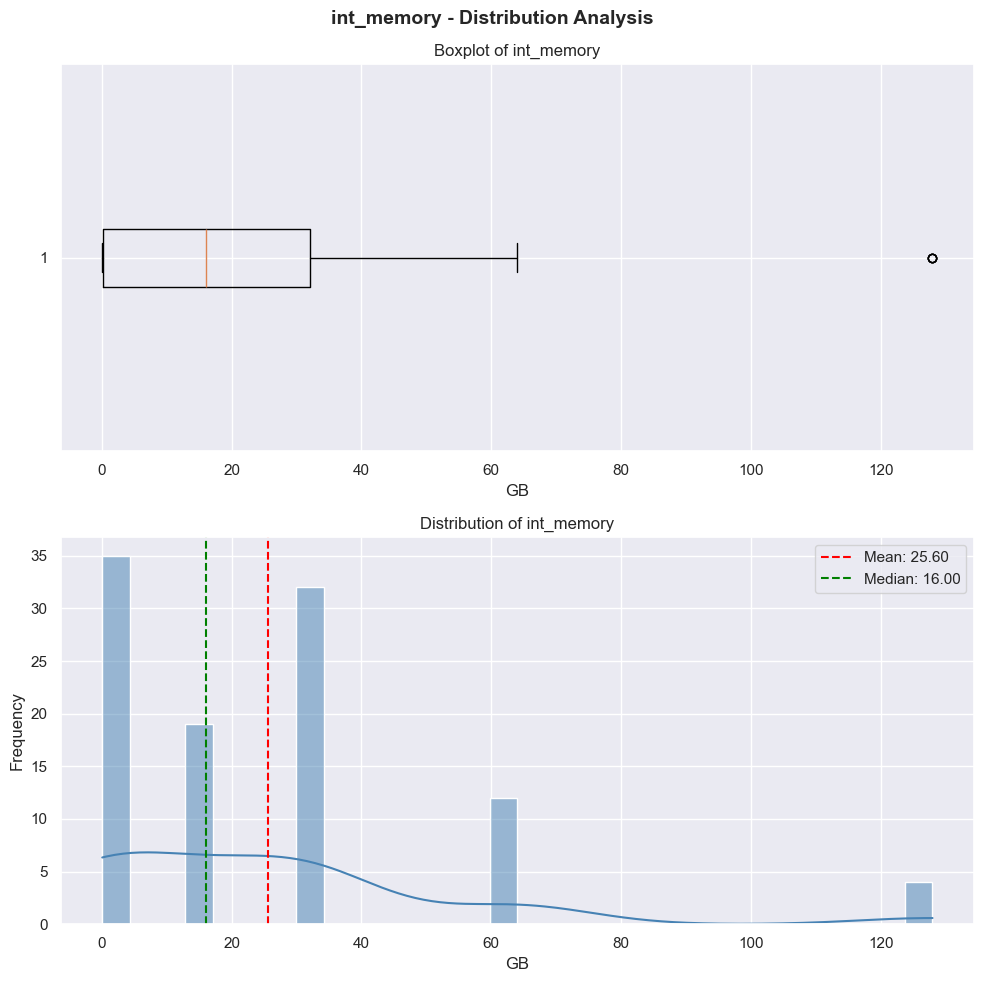

In [74]:
#Looking specifically at Nokia phones distribution
plot_distribution(df[df['brand_name'] == 'Nokia'], 'int_memory', xlabel = 'GB')

In [75]:
#Describe Nokia Internal Memory Distribution
describe_distribution(df[df['brand_name'] == 'Nokia'], 'int_memory')

Lower Outlier Fence = -47.74999999999999
Upper Outlier Fence = 79.85
Outlier count: 4
Skewness:  1.798255429911019
The distribution is highly skewed to the right.


count   102.000
mean     25.596
std      29.094
min       0.060
25%       0.100
50%      16.000
75%      32.000
max     128.000
Name: int_memory, dtype: float64

**Observations**:

Internal memory specifically for Nokia devices is highly right skewed (versus moderate right skew for all devices)

Mean: 25.596 (vs. 54.5 for all devices)

Median: 16.00 (vs. 32.0 for all devices)

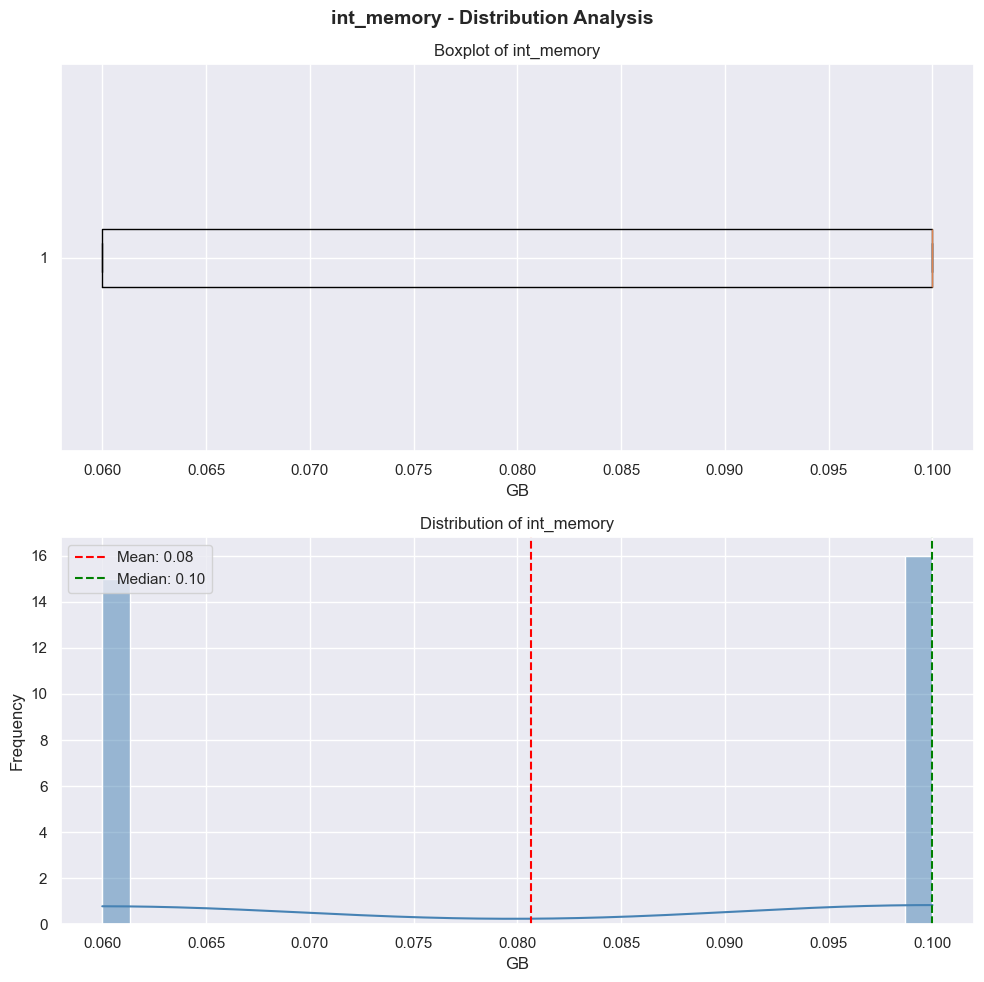

In [76]:
#Looking at distribution of phones filtered on attributes common to all null internal memory rows:
plot_distribution(filtered_int_memory, 'int_memory', xlabel = 'GB')

In [77]:
describe_distribution(filtered_int_memory, 'int_memory')

Lower Outlier Fence = -1.3877787807814457e-17
Upper Outlier Fence = 0.16000000000000003
Outlier count: 0
Skewness:  -0.06787937822424127
The distribution is approximately symmetric.


count   31.000
mean     0.081
std      0.020
min      0.060
25%      0.060
50%      0.100
75%      0.100
max      0.100
Name: int_memory, dtype: float64

**Observations**:

When we filter to all rows with attributes matching those common to all of the null internal memory rows we see that the data is quite symmetric.

I will impute the missing internal memory values with the mean from the set filtered_int_memory.

0.081 GB ≈ 81MB of internal memory. These are clearly basic Nokia devices — not smartphones. These devices represent a distinct sub-population in the dataset, which could be relevant later when interpreting model coefficients.

It is important to note here that the devices most similar to the ones with  null values have a mean and median internal memory that is very far below those of the global mean and median.  For the purpose of accuracy, I am imputing with the values from the subset of most similar devices.

Note: an alternate method considered was imputing with the median value of .100 since this value exists in the table already and does not create a new value. However, I went with the mean here because there are multiple missing values that seem equally likely to be .060 or .100 in value.

In [78]:
#Impute internal memory values:
df['int_memory'] = df['int_memory'].fillna(filtered_int_memory['int_memory'].mean())

#Check that imputation worked:
print(df['int_memory'].isnull().sum())

0


### Investigating RAM Null Values

In [79]:
#Display ram null values
ram_null = df[df['ram'].isnull()]
ram_null

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
114,Nokia,Others,5.180,no,no,0.300,0.000,0.060,NaN,1020.000,91.300,2020,288,2.729,2.911
335,Nokia,Others,5.180,no,no,0.300,0.000,0.100,NaN,1200.000,88.200,2020,327,3.063,3.689
2059,Nokia,Others,5.180,no,no,0.300,0.000,0.060,NaN,NaN,82.600,2016,1023,2.765,3.658
2090,Nokia,Others,7.620,no,no,5.000,0.000,0.060,NaN,1200.000,111.400,2013,1001,3.828,4.606


**Observations**:

All devices missing Ram values are Nokias

All are Operating System 'Other'

All lack both 4g and 5g

3/4 have a .3MP as the main camera value

All lack a selfie camera

In [80]:
#Filtering the main set by characteristics common to all devices with null Ram values
filtered_ram = df[(df['brand_name'] == 'Nokia') & (df['os'] == 'Others') & (df['4g'] == 'no') & (df['5g'] == 'no') & (df['selfie_camera_mp'] == 0.000) & (df['int_memory'] == 0.060)]
filtered_ram

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
114,Nokia,Others,5.180,no,no,0.300,0.000,0.060,NaN,1020.000,91.300,2020,288,2.729,2.911
116,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.020,1200.000,88.200,2020,266,3.371,3.699
332,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.030,1020.000,90.500,2020,322,2.519,3.386
2058,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.020,NaN,81.000,2016,815,2.719,3.375
2059,Nokia,Others,5.180,no,no,0.300,0.000,0.060,NaN,NaN,82.600,2016,1023,2.765,3.658
2060,Nokia,Others,5.280,no,no,2.000,0.000,0.060,0.020,1200.000,91.800,2015,867,2.935,4.220
2061,Nokia,Others,5.280,no,no,2.000,0.000,0.060,0.030,1200.000,91.800,2015,772,3.285,4.248
2063,Nokia,Others,5.180,no,no,2.000,0.000,0.060,0.030,1100.000,79.000,2015,798,3.031,3.701
2065,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.020,1100.000,78.600,2015,682,2.935,3.401
2083,Nokia,Others,5.280,no,no,1.300,0.000,0.060,0.030,1830.000,89.300,2014,717,3.542,4.103


**Observations**:

There are only two unique values for ram in this subset: .2 and .3

There are no obvious commonalities to differentiate further, so it is most reasonable to impute with the mean or median of this subset.

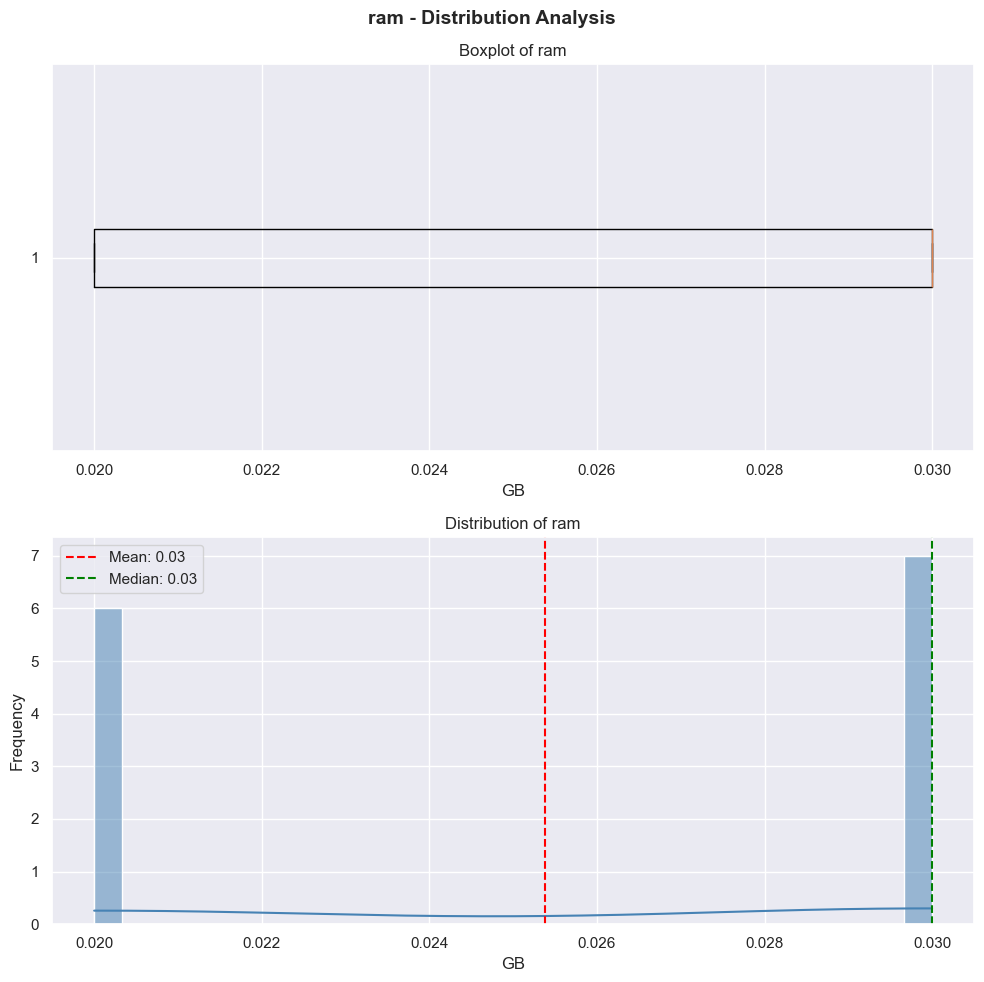

In [81]:
#Looking at distribution of phones filtered on attributes common to all null internal memory rows:
plot_distribution(filtered_ram, 'ram', xlabel = 'GB')

In [82]:
describe_distribution(filtered_ram, 'ram')

Lower Outlier Fence = 0.005000000000000003
Upper Outlier Fence = 0.045
Outlier count: 0
Skewness:  -0.17520438393808055
The distribution is approximately symmetric.


count   13.000
mean     0.025
std      0.005
min      0.020
25%      0.020
50%      0.030
75%      0.030
max      0.030
Name: ram, dtype: float64

**Observations**:

Since the distribution is approximately symmetric I will impute with the mean value 0.025

Note: an alternate method considered was imputing with the median value of .030 since this value exists in the table already and does not create a new value.  However, I went with the mean here because there are multiple missing values that seem equally likely to be .2 or .3 in value.

In [83]:
#Impute RAM values:
df['ram'] = df['ram'].fillna(filtered_ram['ram'].mean())

#Check that imputation worked:
print(df['ram'].isnull().sum())

0


### Investigating Battery Null Values

In [84]:
#Display battery null values
battery_null = df[df['battery'].isnull()]
battery_null

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
1829,Meizu,Android,12.830,yes,no,13.000,5.000,16.000,4.000,NaN,145.000,2014,986,4.178,4.864
1831,Meizu,Android,12.830,yes,no,20.700,5.000,16.000,4.000,NaN,158.000,2014,1043,4.879,5.991
1832,Meizu,Android,13.610,yes,no,20.700,2.000,16.000,4.000,NaN,147.000,2014,1007,4.742,5.826
1962,Microsoft,Windows,25.550,no,no,5.000,3.500,32.000,4.000,NaN,675.900,2013,931,5.231,5.803
2058,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.020,NaN,81.000,2016,815,2.719,3.375
2059,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.025,NaN,82.600,2016,1023,2.765,3.658
3064,ZTE,Android,10.190,yes,no,5.000,8.000,32.000,4.000,NaN,165.000,2019,383,4.799,6.109


**Observations**:

For battery null values we see more varied data than some of the other null values.  4 different brands, at lest 3 different operating systems, a mix of 4g availability, etc.

The only across the board commonality is none of the devices have 5g.

Within like brands we see:

The two Nokias have the same values for Screen size, 4g, 5g, main camera, selfie camera, internal memory, and release year.  It is important to note here that row 2059 has an imputed ram and that value was originally NaN, so it cannot be accurately compared as similar or dissimilar.

The three Meizus have the same operating system, 4g, 5g, internal memory, ram, and release year.

In [85]:
#Looking at all Nokias with like features to the null battery value rows
filtered_battery_nokia = df[(df['brand_name'] == 'Nokia') & (df['os'] == 'Others') & (df['screen_size'] == 5.180) & (df['4g'] == 'no') & (df['5g'] == 'no') & (df['main_camera_mp'] == 0.300) & (df['selfie_camera_mp'] == 0.000) & (df['int_memory'] == 0.060)]
filtered_battery_nokia

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
114,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.025,1020.000,91.300,2020,288,2.729,2.911
116,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.020,1200.000,88.200,2020,266,3.371,3.699
332,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.030,1020.000,90.500,2020,322,2.519,3.386
2058,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.020,NaN,81.000,2016,815,2.719,3.375
2059,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.025,NaN,82.600,2016,1023,2.765,3.658
2065,Nokia,Others,5.180,no,no,0.300,0.000,0.060,0.020,1100.000,78.600,2015,682,2.935,3.401


**Observations**:

If we filter on all commonalities for the two Nokias we are left with only the null, but if we remove release year and filter on all other commonalities we are left with a set of nearly identical phones released in different years with similar battery values.

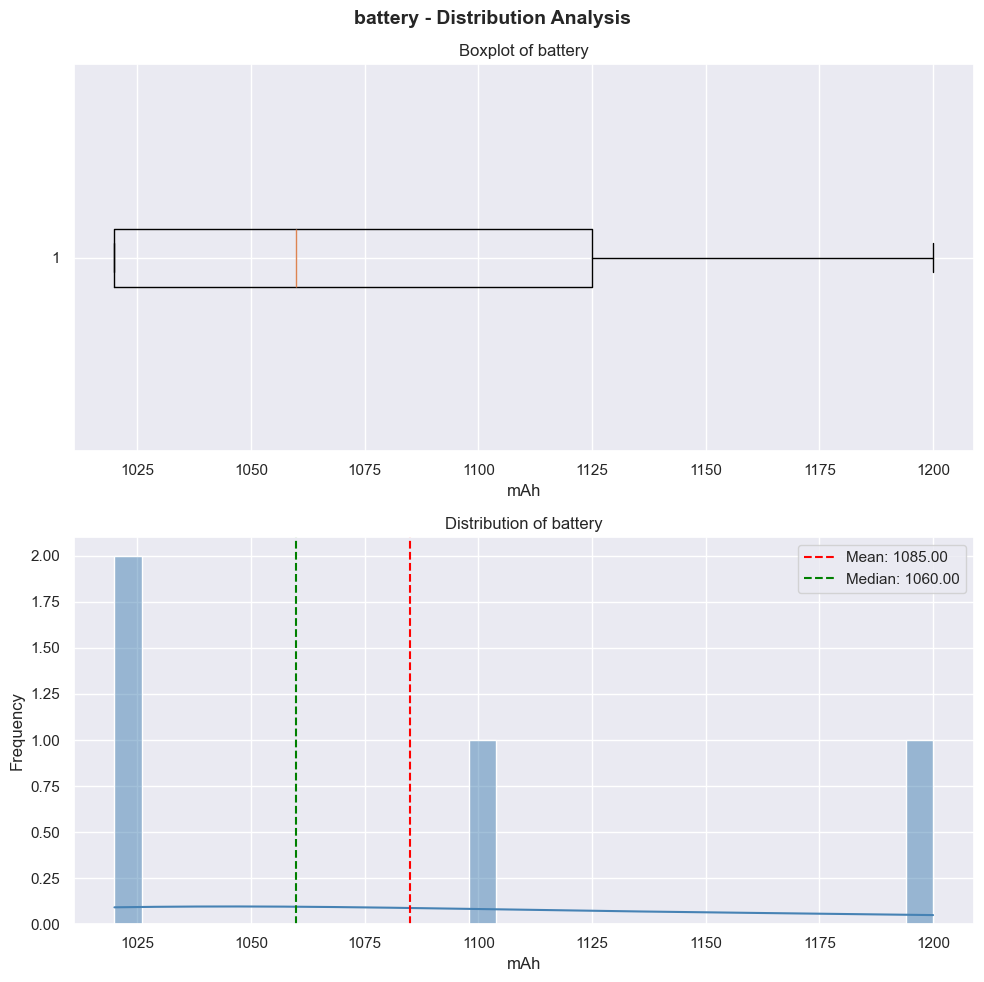

In [86]:
#Checking the distribution of this filtered data
plot_distribution(filtered_battery_nokia, 'battery', xlabel = 'mAh')

In [87]:
describe_distribution(filtered_battery_nokia, 'battery')

Lower Outlier Fence = 862.5
Upper Outlier Fence = 1282.5
Outlier count: 0
Skewness:  1.0421472010614363
The distribution is highly skewed to the right.


count      4.000
mean    1085.000
std       85.440
min     1020.000
25%     1020.000
50%     1060.000
75%     1125.000
max     1200.000
Name: battery, dtype: float64

**Observations**:

Comparing the data with the description of all data above we see

Filtered Mean: 1085 vs. 3133.403 global

Filtered Median 1060 vs. 3000 global

Because there is a large difference between this subset of similar devices and the global I will use the subset to impute.

Because the subset is highly skewed right, I will use the median value (as opposed to mean).

Note: with such a small sample for comparison (4 like devices) there is some uncertainty in this imputation estimate.

In [88]:
#Impute the Nokias with null battery values
df.loc[(df['brand_name'] == 'Nokia') & (df['battery'].isna()), 'battery'] = filtered_battery_nokia['battery'].median()

#Check that imputation worked:
print(df['battery'].isnull().sum())

5


**Observations**:

The Nokias have been successfully imputed, next we will look at the Meizus

In [89]:
#Looking at all Meizus with like features to the null battery value rows
filtered_battery_meizu = df[(df['brand_name'] == 'Meizu') & (df['os'] == 'Android') & (df['4g'] == 'yes') & (df['5g'] == 'no') & (df['int_memory'] == 16.000) & (df['ram'] == 4.000)]
filtered_battery_meizu

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
1788,Meizu,Android,13.840,yes,no,13.000,8.000,16.000,4.000,3000.000,150.000,2018,698,4.165,4.491
1796,Meizu,Android,13.840,yes,no,13.000,8.000,16.000,4.000,3070.000,140.000,2018,564,4.463,4.941
1804,Meizu,Android,12.830,yes,no,12.500,16.000,16.000,4.000,4000.000,173.000,2017,786,4.537,5.145
1807,Meizu,Android,12.700,yes,no,8.000,5.000,16.000,4.000,3235.000,135.000,2017,801,3.948,4.936
1809,Meizu,Android,12.750,yes,no,13.000,5.000,16.000,4.000,3000.000,143.000,2017,606,4.071,4.862
1810,Meizu,Android,12.830,yes,no,13.000,5.000,16.000,4.000,3060.000,175.000,2016,789,4.508,5.246
1812,Meizu,Android,12.830,yes,no,16.000,5.000,16.000,4.000,3150.000,149.000,2016,718,4.307,5.236
1824,Meizu,Android,12.830,yes,no,13.000,5.000,16.000,4.000,3140.000,149.000,2015,966,4.428,5.141
1826,Meizu,Android,12.700,yes,no,13.000,5.000,16.000,4.000,3095.000,131.000,2015,791,4.013,4.860
1827,Meizu,Android,12.830,yes,no,20.700,5.000,16.000,4.000,3150.000,149.000,2015,944,4.794,5.341


**Observations**:

Similar to the Nokias above, if we filter on all commonalities for the three Meizus we are left with only the null, but if we remove release year and filter on all other commonalities we are left with a set of nearly identical phones released in different years with similar battery values.

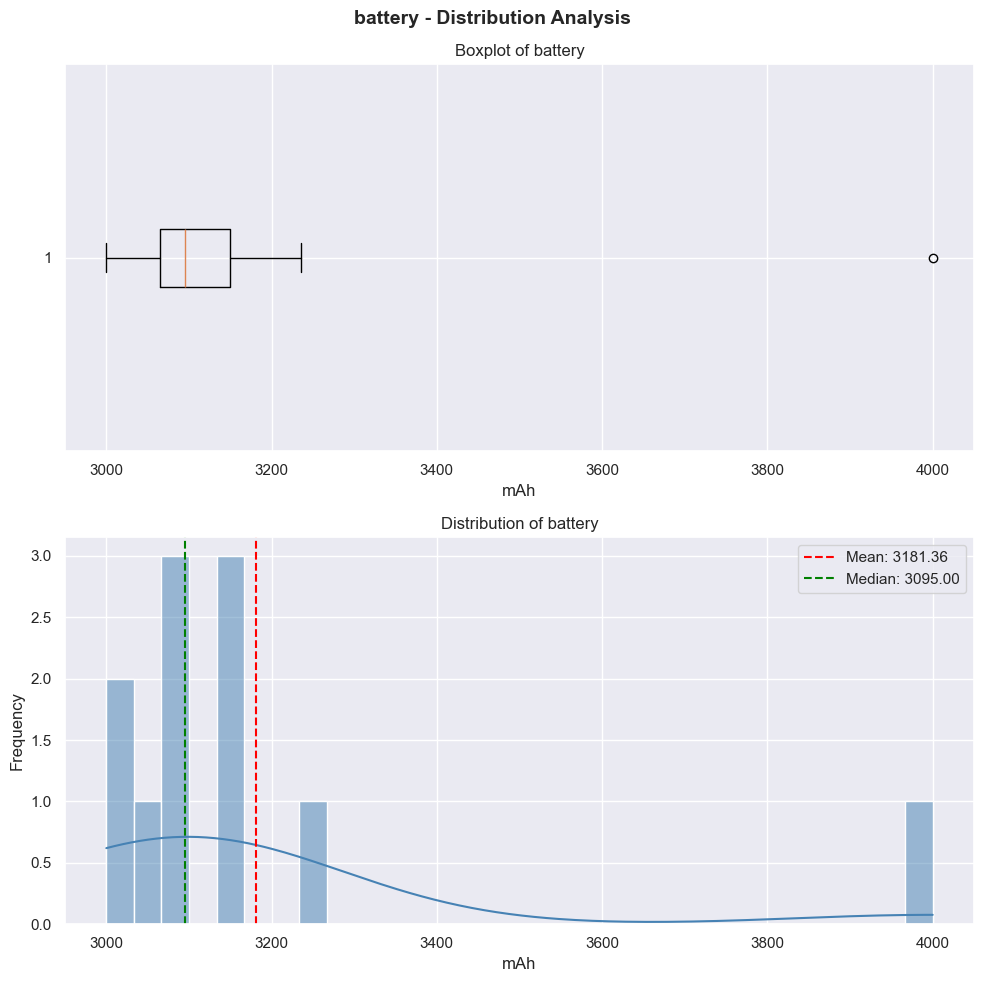

In [90]:
#Checking the distribution of this filtered data
plot_distribution(filtered_battery_meizu, 'battery', xlabel = 'mAh')

In [91]:
describe_distribution(filtered_battery_meizu, 'battery')

Lower Outlier Fence = 2937.5
Upper Outlier Fence = 3277.5
Outlier count: 1
Skewness:  2.9602995881376666
The distribution is highly skewed to the right.


count     11.000
mean    3181.364
std      280.099
min     3000.000
25%     3065.000
50%     3095.000
75%     3150.000
max     4000.000
Name: battery, dtype: float64

**Observations**:

Comparing the data with the description of all data above we see

Filtered Mean: 3181.364 vs. 3133.403 global

Filtered Median 3095 vs. 3000 global

Here there is not a large difference to the global values, but for the sake of accuracy and consistency we will utilize the filtered data to impute.

Because the subset is highly skewed right, I will use the median value (as opposed to mean).

In [92]:
#Impute the Meizus with null battery values
df.loc[(df['brand_name'] == 'Meizu') & (df['battery'].isna()), 'battery'] = filtered_battery_meizu['battery'].median()

#Check that imputation worked:
print(df['battery'].isnull().sum())

2


**Observations**:

The Meizus have been successfully imputed, next we will look at the remaining Microsoft device.

In [93]:
#Looking at all Microsofts devices
filtered_battery_microsoft = df[(df['brand_name'] == 'Microsoft')]
filtered_battery_microsoft

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
1941,Microsoft,Windows,12.700,yes,no,8.000,5.000,16.000,4.000,2000.000,122.000,2016,961,4.034,5.009
1942,Microsoft,Windows,12.880,yes,no,20.000,5.000,32.000,4.000,3340.000,165.000,2015,931,4.960,5.856
1943,Microsoft,Windows,12.880,yes,no,20.000,5.000,32.000,4.000,3340.000,165.000,2015,820,4.910,5.853
1944,Microsoft,Windows,12.750,yes,no,20.000,5.000,32.000,4.000,3000.000,150.000,2015,692,4.845,5.632
1945,Microsoft,Windows,12.750,yes,no,20.000,5.000,32.000,4.000,3000.000,150.000,2015,751,4.684,5.636
1946,Microsoft,Windows,10.340,yes,no,5.000,2.000,32.000,4.000,2100.000,141.900,2015,790,3.819,4.498
1947,Microsoft,Windows,12.700,no,no,8.000,5.000,32.000,4.000,2200.000,152.000,2015,965,3.965,4.612
1948,Microsoft,Windows,10.160,no,no,2.000,0.300,32.000,4.000,1500.000,127.900,2015,890,3.386,4.237
1949,Microsoft,Windows,12.880,yes,no,13.000,5.000,32.000,4.000,3000.000,171.000,2015,823,4.429,5.306
1950,Microsoft,Windows,12.880,yes,no,13.000,5.000,32.000,4.000,3000.000,171.000,2015,956,4.195,5.297


**Observations**:

Filtering first to Microsoft devices I found that screen size and weight set this device apart from all the others - tablet vs phones.  For this reason, I am not filtering on brand but Screen Size and weight to capture similar size tablets/devices.



In [94]:
#Filtering to like tablets:
filtered_battery_tablet = df[(df['screen_size'] > 20) & (df['weight'] > 500.000) & (df['release_year'].between(2013, 2016))]
filtered_battery_tablet

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
75,Lenovo,Android,25.430,yes,no,8.000,8.000,16.000,2.000,8400.000,655.000,2016,691,5.056,5.191
294,Lenovo,Android,25.430,yes,no,8.000,8.000,16.000,2.000,8400.000,655.000,2016,902,4.867,5.188
403,Acer,Android,25.430,no,no,5.000,2.000,16.000,1.000,2700.000,508.000,2014,578,4.837,5.258
404,Acer,Android,25.430,no,no,5.000,2.000,32.000,2.000,2700.000,508.000,2014,918,4.691,5.438
433,Acer,Android,25.430,no,no,5.000,2.000,16.000,4.000,5910.000,540.000,2015,899,4.624,5.518
460,Acer,Android,25.430,no,no,5.000,0.300,16.000,4.000,7300.000,560.000,2013,656,4.612,5.243
612,Others,Android,23.040,no,no,2.000,0.300,32.000,4.000,8000.000,645.400,2013,579,4.830,5.069
662,Apple,iOS,30.710,yes,no,8.000,1.200,32.000,4.000,3937.000,713.000,2015,572,5.559,6.745
749,Asus,Android,25.430,no,no,5.000,2.000,32.000,4.000,4890.000,510.000,2015,999,4.783,5.080
773,Asus,Android,25.430,no,no,5.000,0.300,32.000,4.000,5000.000,525.000,2014,1059,4.727,5.298


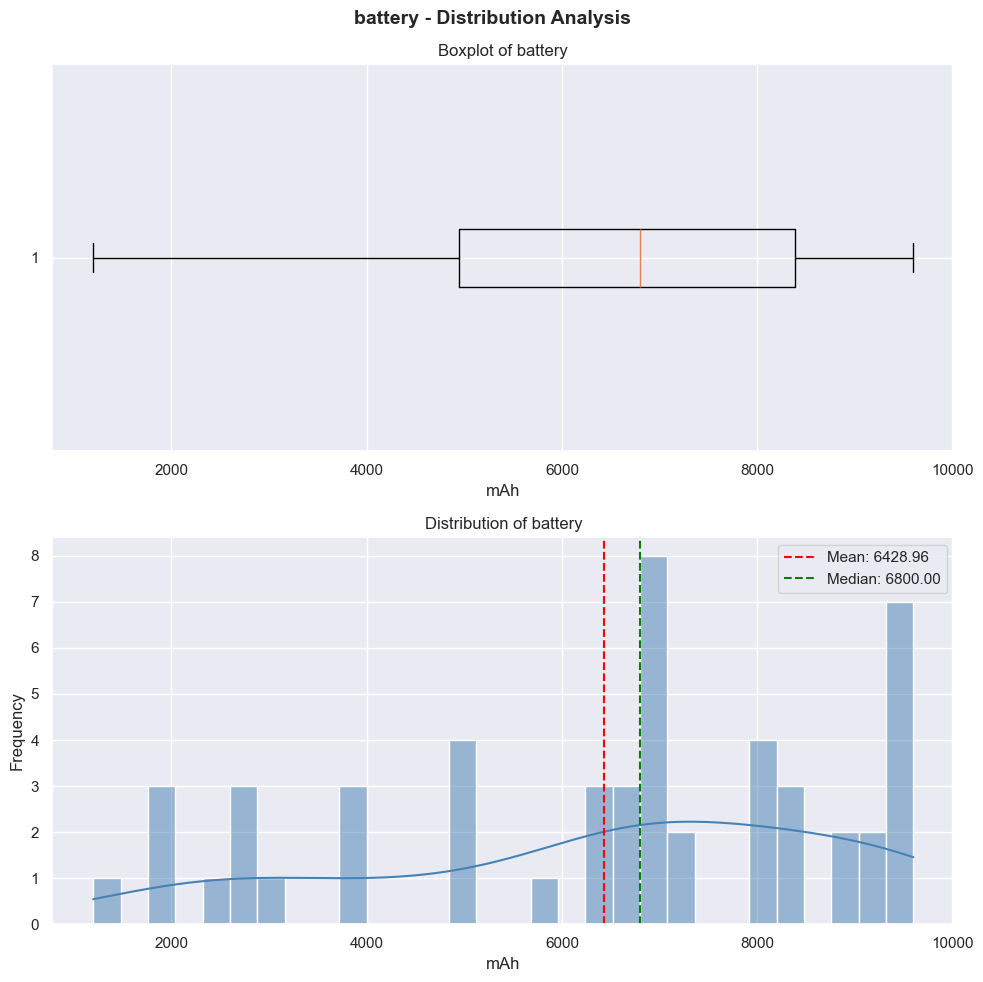

In [95]:
plot_distribution(filtered_battery_tablet, 'battery', xlabel = 'mAh')

In [96]:
describe_distribution(filtered_battery_tablet, 'battery')

Lower Outlier Fence = -222.5
Upper Outlier Fence = 13557.5
Outlier count: 0
Skewness:  -0.5433985337959997
The distribution is moderately skewed to the left.


count     51.000
mean    6428.961
std     2459.989
min     1200.000
25%     4945.000
50%     6800.000
75%     8390.000
max     9600.000
Name: battery, dtype: float64

**Observations**:

Comparing the data with the description of all data above we see

Filtered Mean: 6428.961 vs. 3133.403 global

Filtered Median 6800 vs. 3000 global

Because there is a large difference between this subset of similar devices and the global I will use the subset to impute.

Because the subset is moderately skewed left, I will use the median value.

In [97]:
#Impute the Microsoft with null battery value
df.loc[(df['brand_name'] == 'Microsoft') & (df['battery'].isna()), 'battery'] = filtered_battery_tablet['battery'].median()

#Check that imputation worked:
print(df['battery'].isnull().sum())

1


**Observations**:

The null Microsoft battery value has been successfully imputed.

In [98]:
#Describing the set of all ZTE devices:
filtered_battery_zte = df[(df['brand_name'] == 'ZTE')]
describe_distribution(filtered_battery_zte, 'battery')

Lower Outlier Fence = 787.5
Upper Outlier Fence = 4687.5
Outlier count: 10
Skewness:  0.6455655247523631
The distribution is moderately skewed to the right.


count    139.000
mean    2912.050
std      912.556
min     1200.000
25%     2250.000
50%     3000.000
75%     3225.000
max     5100.000
Name: battery, dtype: float64

**Observations**

Looking at all ZTE devices we see a minimum of 1200 mAh and maximum of 5100 which reinforces our earlier research and the decision to reject the 500 value.

In [99]:
#Filtering to like devices on columns with high impact on battery:
filtered_battery_zte_further = df[(df['screen_size'].between(5, 15)) & (df['weight'].between(115, 215)) & (df['release_year'].between(2018, 2020))]
filtered_battery_zte_further

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.500,yes,no,13.000,5.000,64.000,3.000,3020.000,146.000,2020,127,4.308,4.715
6,Honor,Android,13.840,yes,no,8.000,5.000,32.000,2.000,3020.000,144.000,2020,234,3.878,4.519
14,Honor,Android,14.500,yes,no,13.000,5.000,32.000,2.000,3020.000,146.000,2019,230,4.111,4.488
18,Honor,Android,14.500,yes,no,13.000,5.000,32.000,2.000,3020.000,146.000,2019,532,4.249,4.792
23,HTC,Android,12.880,yes,no,13.000,13.000,64.000,4.000,3075.000,150.000,2019,499,4.596,5.398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3430,Samsung,Android,12.880,yes,no,12.000,5.000,16.000,2.000,3000.000,149.000,2019,332,4.153,4.443
3443,Samsung,Android,14.810,yes,no,8.000,5.000,32.000,2.000,3000.000,141.000,2019,383,4.191,4.309
3444,Apple,iOS,10.340,yes,no,12.000,7.000,64.000,3.000,1821.000,148.000,2020,235,5.012,5.875
3446,Apple,iOS,12.900,yes,no,8.000,7.000,64.000,4.000,3046.000,188.000,2019,351,5.440,6.714


**Observations**

Filtering on like attributes of similar size (+/- ~5cm), weight (+/- ~50gm), and release year (+/-1), we get a robust subset of 189 devices to impute from

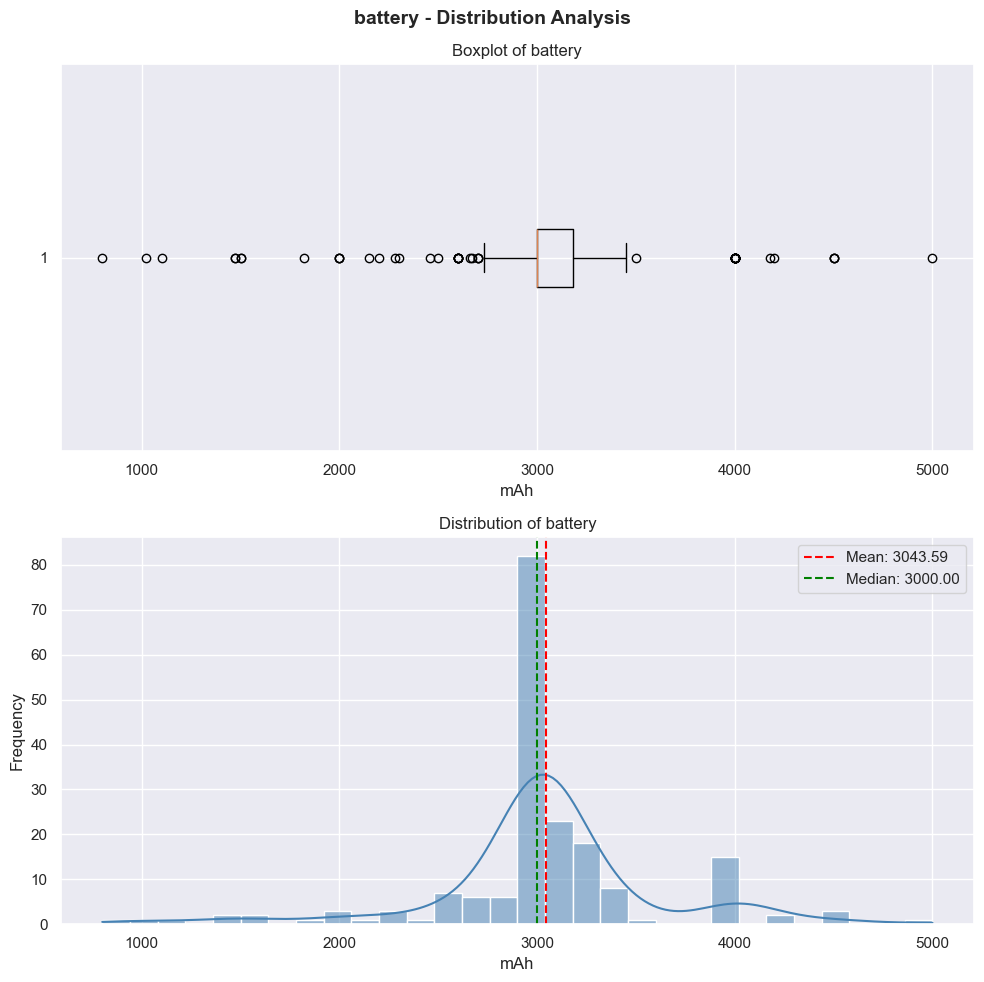

In [100]:
#Show distribution of filtered ZTE devices
plot_distribution(filtered_battery_zte_further, 'battery', 'mAh')

In [101]:
describe_distribution(filtered_battery_zte_further, 'battery')

Lower Outlier Fence = 2730.0
Upper Outlier Fence = 3450.0
Outlier count: 50
Skewness:  -0.48822228870791334
The distribution is approximately symmetric.


count    188.000
mean    3043.590
std      574.648
min      800.000
25%     3000.000
50%     3000.000
75%     3180.000
max     5000.000
Name: battery, dtype: float64

**Observations**
Comparing the filtered data with the description of all data above we see

Filtered Mean: 2912.05 vs.3133.403  global

Filtered Median 3000 vs. 3000 global

Though not a large difference from the global data, I will use this subset of similar devices for the sake of accuracy and consistency.

Because the subset is approximately symmetric, I will use the mean value to impute.

In [102]:
#Impute the null zte value
df.loc[(df['brand_name'] == 'ZTE') & (df['battery'].isna()), 'battery'] = filtered_battery_zte_further['battery'].mean()

#Check that imputation worked:
print(df['battery'].isnull().sum())

0


**Observations**

All battery values have been imputed successfully.

### Investigating Weight Null Values

In [103]:
#Display weight null values
weight_null = df[df['weight'].isnull()]
weight_null

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
3002,XOLO,Android,12.700,yes,no,13.000,5.000,32.000,4.000,2400.000,NaN,2015,576,4.166,4.930
3003,XOLO,Android,12.830,yes,no,8.000,5.000,16.000,4.000,3200.000,NaN,2015,800,4.282,5.189
3004,XOLO,Android,12.700,no,no,8.000,2.000,32.000,4.000,2100.000,NaN,2015,878,3.880,4.081
3005,XOLO,Android,10.290,no,no,5.000,0.300,32.000,4.000,1800.000,NaN,2015,1036,3.824,4.396
3006,XOLO,Android,12.700,no,no,5.000,0.300,16.000,4.000,2500.000,NaN,2015,679,3.837,4.347
3007,XOLO,Windows,12.700,no,no,8.000,2.000,32.000,4.000,2200.000,NaN,2015,838,3.707,4.792
3008,XOLO,Android,12.700,no,no,8.000,5.000,32.000,4.000,2500.000,NaN,2015,1045,4.185,4.785


In [104]:
#Filter to like products of a similar size, battery capacity, and release year as these likely impact weight
filtered_weight = df[(df['brand_name'] == 'XOLO') & (df['screen_size'].between(10, 13)) & (df['battery'].between(1500, 3500)) & (df['release_year'].between(2013, 2018))]
filtered_weight

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
3002,XOLO,Android,12.700,yes,no,13.000,5.000,32.000,4.000,2400.000,NaN,2015,576,4.166,4.930
3003,XOLO,Android,12.830,yes,no,8.000,5.000,16.000,4.000,3200.000,NaN,2015,800,4.282,5.189
3004,XOLO,Android,12.700,no,no,8.000,2.000,32.000,4.000,2100.000,NaN,2015,878,3.880,4.081
3005,XOLO,Android,10.290,no,no,5.000,0.300,32.000,4.000,1800.000,NaN,2015,1036,3.824,4.396
3006,XOLO,Android,12.700,no,no,5.000,0.300,16.000,4.000,2500.000,NaN,2015,679,3.837,4.347
3007,XOLO,Windows,12.700,no,no,8.000,2.000,32.000,4.000,2200.000,NaN,2015,838,3.707,4.792
3008,XOLO,Android,12.700,no,no,8.000,5.000,32.000,4.000,2500.000,NaN,2015,1045,4.185,4.785
3009,XOLO,Android,12.830,no,no,13.000,2.000,32.000,4.000,2600.000,120.000,2014,1008,3.916,4.864
3010,XOLO,Android,12.700,no,no,8.000,2.000,32.000,4.000,2100.000,120.000,2014,782,3.994,4.698
3011,XOLO,Android,12.700,no,no,8.000,5.000,32.000,4.000,2500.000,120.000,2014,956,3.978,4.791


**Observations**:

Filtering on brand, screen size, battery capacity, and year, we can get a subset of very similar devices with fairly similar weights to more accurately impute from.

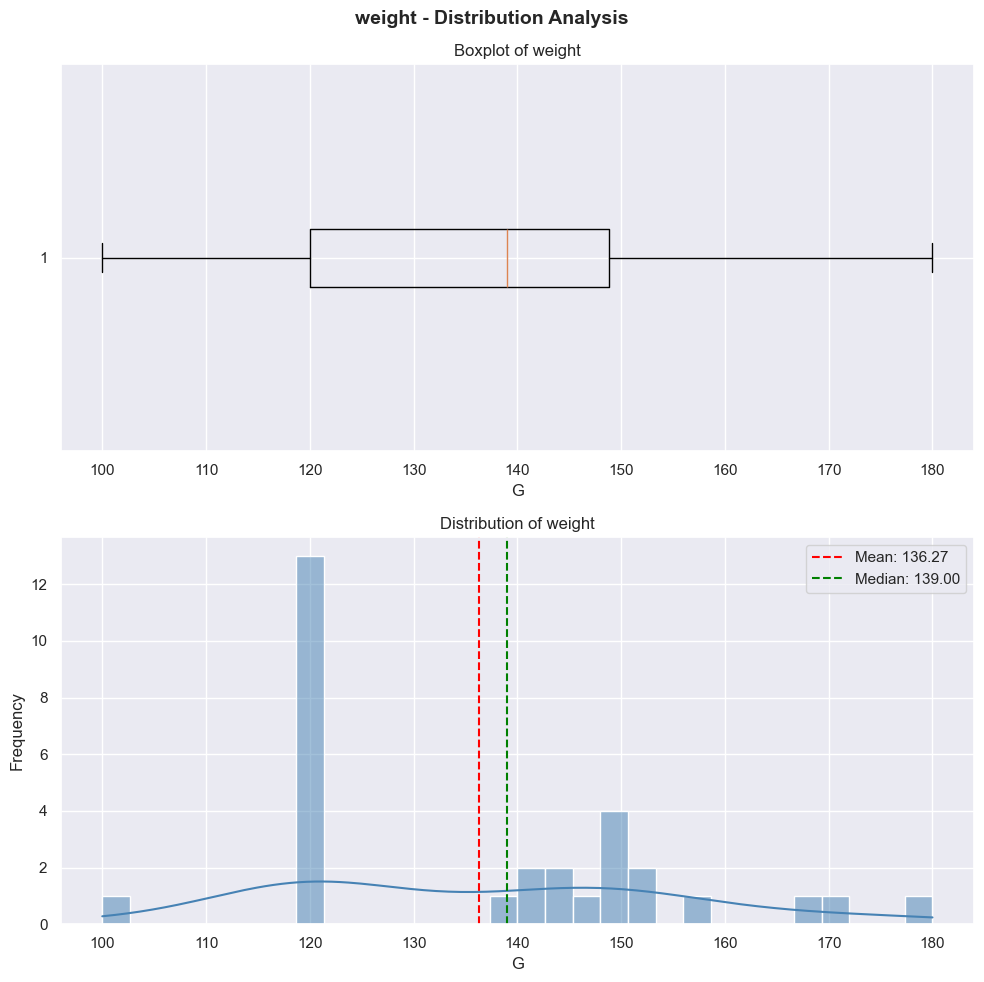

In [105]:
plot_distribution(filtered_weight, 'weight', xlabel = 'G')

In [106]:
describe_distribution(filtered_weight, 'weight')

Lower Outlier Fence = 76.72500000000001
Upper Outlier Fence = 192.125
Outlier count: 0
Skewness:  0.41469416328030273
The distribution is approximately symmetric.


count    30.000
mean    136.265
std      19.190
min     100.000
25%     120.000
50%     139.000
75%     148.850
max     180.000
Name: weight, dtype: float64

**Observations**:

Comparing the filtered data with the description of all data above we see

Filtered Mean: 136.265 vs. 182.752 global

Filtered Median 139 vs. 160 global

Though not a large difference from the global data, I will use this subset of similar devices for the sake of accuracy and consistency.

Because the subset is approximately symmetric, I will use the mean value.

In [107]:
#Impute null weight values:
df['weight'] = df['weight'].fillna(filtered_weight['weight'].mean())

#Check that imputation worked:
print(df['weight'].isnull().sum())

0


**Observations**:

Weight values have been successfully imputed.

### Adding Feature - Years Past Release

**Observations**

Unless there is a special, limited release or short run of a trendy device it seems unlikely that device value is directly related to release year.  It is more likely that value is related to how antiquated a device is (ie how far from the release date).  So, we will adjust the table to measure years past release rather than specific release year.

The following code was written to measure from the current year, however for this project the data was said to be collected in 2021, so we will manually compare to that year below.   

In [108]:
#Uncomment to run current year - release year

#Import datetime
#from datetime import datetime

#Define Current Year
#current_year = datetime.now().year

#Add the new column for years past release year
#df1['yrs_past_release'] = current_year - df1['release_year']

#Drop the release_year prior to our multi-variate EDA
#df1.drop('release_year', axis = 1, inplace = True)

#df1.head()

In [109]:
#2021 Data Collection - release year: (comment out if running above block instead)

#Make a Copy of the table with release year changed to years past release.
df1 = df.copy()

#Add the new column for years past release year
df1['yrs_past_release'] = 2021 - df1['release_year']

#Drop the release_year prior to our multi-variate EDA
df1.drop('release_year', axis = 1, inplace = True)

df1.head()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_used_price,normalized_new_price,yrs_past_release
0,Honor,Android,14.500,yes,no,13.000,5.000,64.000,3.000,3020.000,146.000,127,4.308,4.715,1
1,Honor,Android,17.300,yes,yes,13.000,16.000,128.000,8.000,4300.000,213.000,325,5.162,5.519,1
2,Honor,Android,16.690,yes,yes,13.000,8.000,128.000,8.000,4200.000,213.000,162,5.111,5.885,1
3,Honor,Android,25.500,yes,yes,13.000,8.000,64.000,6.000,7250.000,480.000,345,5.135,5.631,1
4,Honor,Android,15.320,yes,no,13.000,8.000,64.000,3.000,5000.000,185.000,293,4.390,4.948,1


**Observations**
  
Years since release is more interpretable and meaningful than raw release year since it captures device age relative to data collection.

## EDA - Multivariate

Now that we've cleaned up the data for modeling let's take a deeper look with some multivariate analysis

### Correlation Heat Map

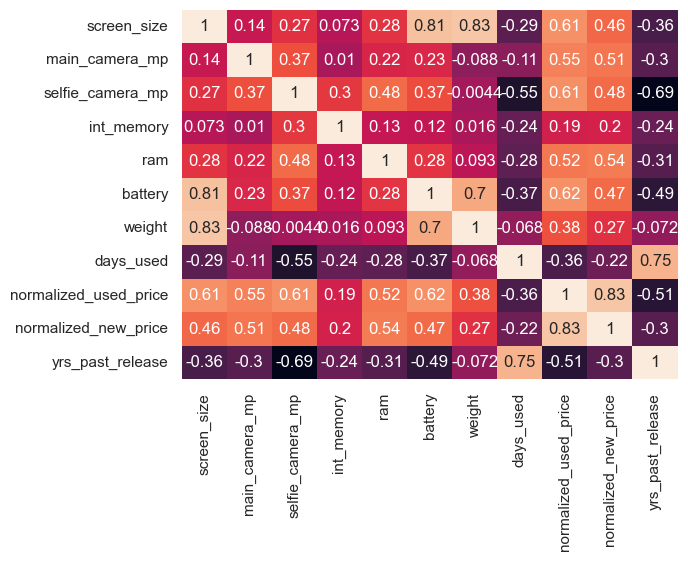

In [110]:
# Heatmap of numeric values
sns.heatmap(data = df1.select_dtypes(include='number').corr(), annot=True, cbar=False)
plt.show()

**Observations**

**Very Strong Correlations** (.7+):

-Screen Size + Weight (.83)

-Used Price + New Price (.83)

-Screen Size + Battery (.81)

-Days Used + Years Past release (.75)

-Battery + Weight (.7)

There are no surprises among the very strong correlations.



**Strong Correlations** (.5-.7):

-Selfie Camera Resolution + Years Past Release (-.69)

-Battery + Used Price (.62)

-Screen Size + Used Price (.61)

-Selfie Camera Resolution + Used Price (.61)

-Main Camera Resolution + Used Price (.55)

-Selfie Camera Resolution + Days Used (-.55)

-Ram + New Price (.54)

-Ram + Used Price (.52)

-Main Camera Resolution + Used Price (.51)

-Used Price + Years past release (-.51)

There are no surprises among the strong correlations.


**Moderate Correlations** (.3-.5):

-Selfie Camera Resolution+ Ram (.48)

-Selfie Camera Resolution + Used Price (.48)

-Screen Size + New Price (.46)

-Battery + Years past release (-.49)

-Battery + New Price (.47)

-Weight + Used Price (.38)

-Main Camera Resolution + Selfie Camera Resolution (.37)

-Selfie Camera + Battery (.37)

-RAM + Days Used (-.37)

-Screen Size + Years Past release (-.36)

-Days Used + Used Price (-.36)

-RAM + Years Past Release (-.31)

-Main Camera Resolution + Years past release (-.3)

-Selfie Camera Resolution + Internal Memory (.3)

-New Price + Years Past Release (-.3)

There are no surprises among the moderate correlations.

**Project Question Answered**

7.	Which attributes are highly correlated with the normalized price of a used device?

Strong: screen_size, main_camera_mp, selfie_camera_mp, ram, battery

Very Strong: normalized_new_price

Let's next take a look at some of the categorical relationships not captured by a heatmap.

### Brand v Operating System

In [111]:
#Cross Tab of brand v Operating Systems
pd.crosstab(df1['brand_name'], df1['os'])

os,Android,Others,Windows,iOS
brand_name,,,,
Acer,48,1,2,0
Alcatel,109,12,0,0
Apple,0,3,0,36
Asus,122,0,0,0
BlackBerry,10,12,0,0
Celkon,22,11,0,0
Coolpad,22,0,0,0
Gionee,56,0,0,0
Google,15,0,0,0


**Observations**

Every device brand except Apple and Microsoft has at least some devices on Android.

Every brand except Apple, Microsoft, and Blackberry have the majority of devices on Android.

The slight majority of Blackberry devices run on other operating systems with just under half running on Android.

All Microsoft devices are running on Windows.

The majority of Apple devices run on iOS.  With 3 running on 'other' - let's take a look at those 3.

In [112]:
apples_on_other_os = df1[(df1['brand_name'] == 'Apple') & (df1['os'] == 'Others')].copy()
apples_on_other_os

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_used_price,normalized_new_price,yrs_past_release
388,Apple,Others,30.710,yes,no,12.000,7.000,128.000,6.000,9720.000,641.000,220,5.847,6.907,1
389,Apple,Others,27.940,yes,no,12.000,7.000,128.000,6.000,5770.500,471.000,248,5.691,6.685,1
390,Apple,Others,25.450,yes,no,8.000,1.200,32.000,3.000,8827.000,483.000,313,5.204,5.852,2


**Observations**

Based on the size these are likely ipads (one could be a small macbook).

It should be noted that apple does not sell devices that run on anything other than iOS.  These devices are either an error in recording the OS or a special class of devices that the previous owner tampered with to run a different OS.  For now we will assume the data is correct and the previous owners made some modifications that may affect the resale value.

The data set is too small to give us confidence in a comparison, but let's still compare to see if we see a difference in pricing for these modified devices.

In [113]:
#Define non-tampered with set of Apple devices
apples_on_ios = df1[(df1['brand_name'] == 'Apple') & (df1['os'] == 'iOS')].copy()

Instead of comparing direct value, which can be misleading when comparing say a tablet with a budget phone, let's make a column to reflect loss of value from the normalized new price minus the normalized used price.

In [114]:
#Create columns for value loss
apples_on_other_os['value_loss'] = apples_on_other_os['normalized_new_price'] - apples_on_other_os['normalized_used_price']

apples_on_ios['value_loss'] = apples_on_ios['normalized_new_price'] - apples_on_ios['normalized_used_price']


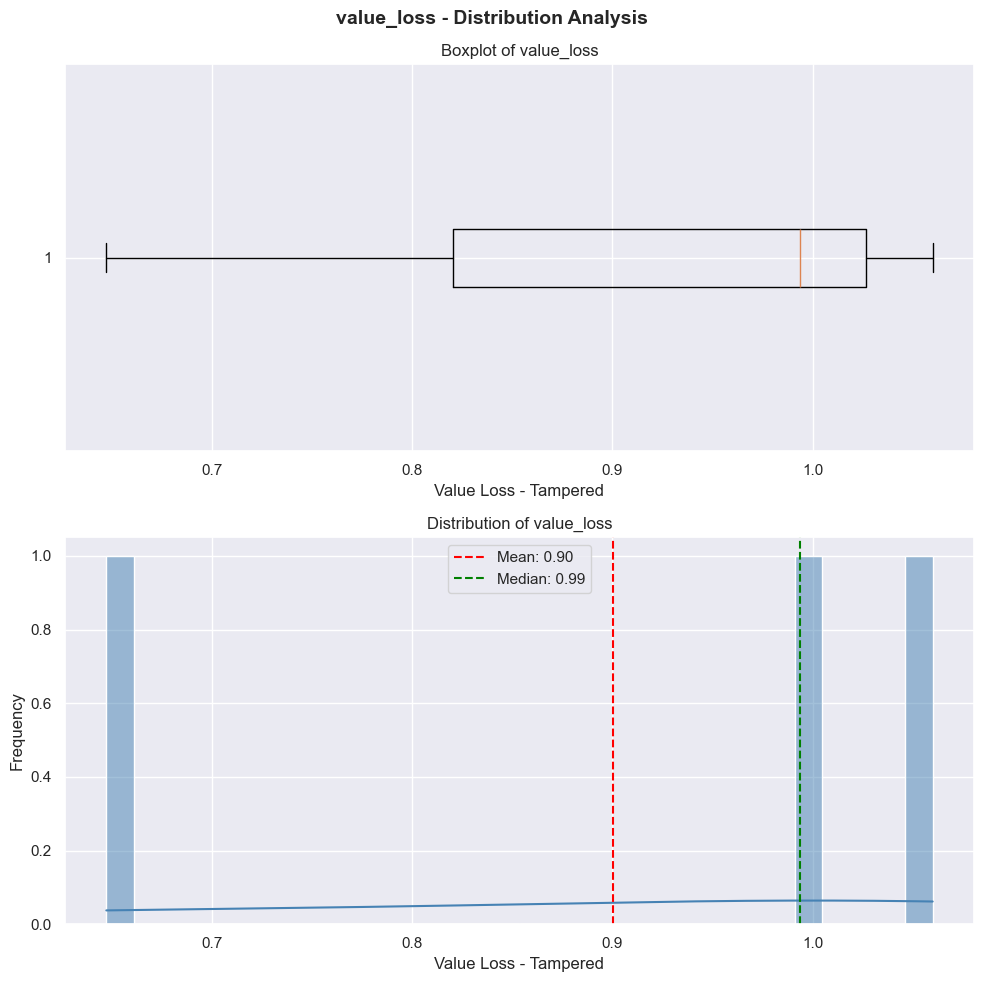

In [115]:
#Display Tampered data
plot_distribution(apples_on_other_os, 'value_loss', 'Value Loss - Tampered')

In [116]:
describe_distribution(apples_on_other_os, 'value_loss')

Lower Outlier Fence = 0.5109784886369553
Upper Outlier Fence = 1.3361568165762907
Outlier count: 0
Skewness:  -1.5583478189281397
The distribution is highly skewed to the left.


count   3.000
mean    0.900
std     0.222
min     0.647
25%     0.820
50%     0.993
75%     1.027
max     1.060
Name: value_loss, dtype: float64

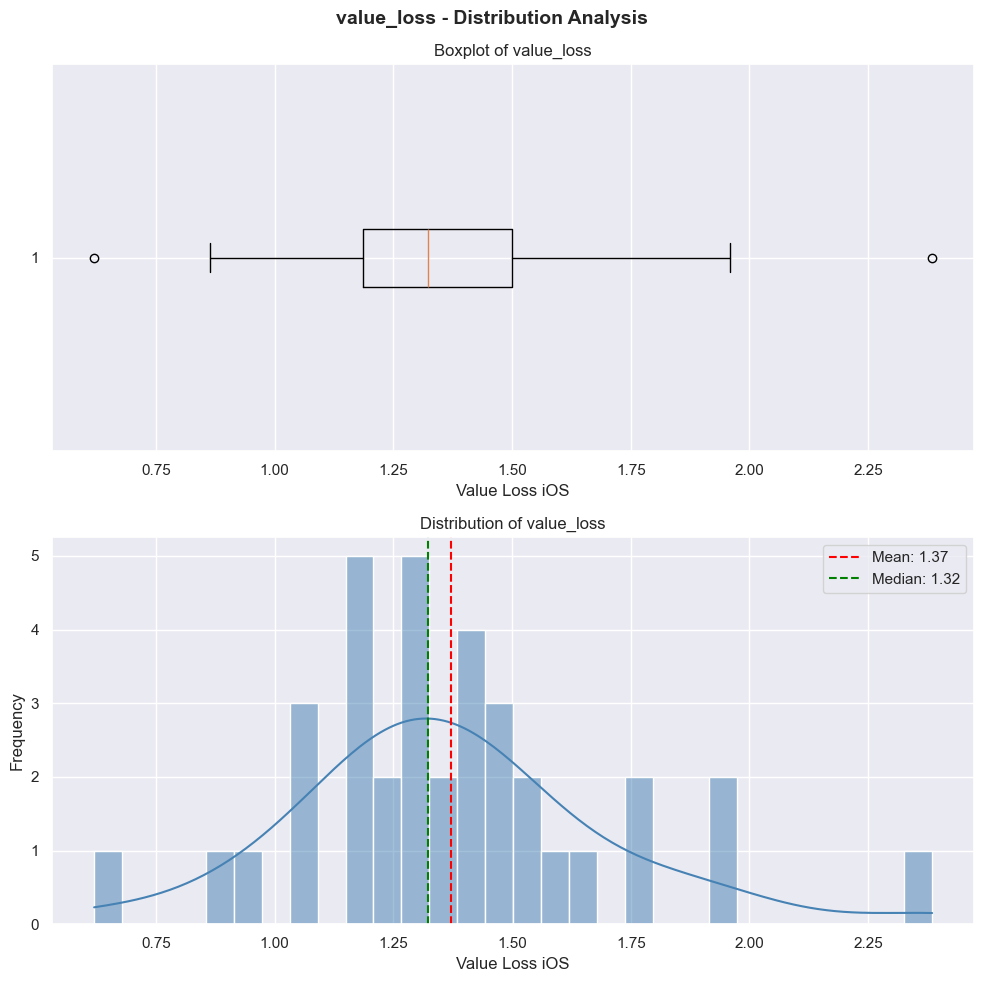

In [117]:
#Plot devices on iOs
plot_distribution(apples_on_ios, 'value_loss', 'Value Loss iOS')

In [118]:
describe_distribution(apples_on_ios, 'normalized_used_price')

Lower Outlier Fence = 3.416777501926372
Upper Outlier Fence = 6.531124834735305
Outlier count: 0
Skewness:  0.09126163816909166
The distribution is approximately symmetric.


count   36.000
mean     4.957
std      0.536
min      3.880
25%      4.585
50%      4.930
75%      5.363
max      6.159
Name: normalized_used_price, dtype: float64

**Observations**

Surprisingly there appears to be more value lost in used Apple devices running on iOS than these devices that have been tampered with to run on Other Operating Systems.  The data is far too small do draw any meaningful conclusions, but this could hint at a niche market for these custom setups.

We won't go through every permutation of all 15 columns, but let's take a look at a few more of the interesting combinations not already captured by the heatmap.

### Brand v Size

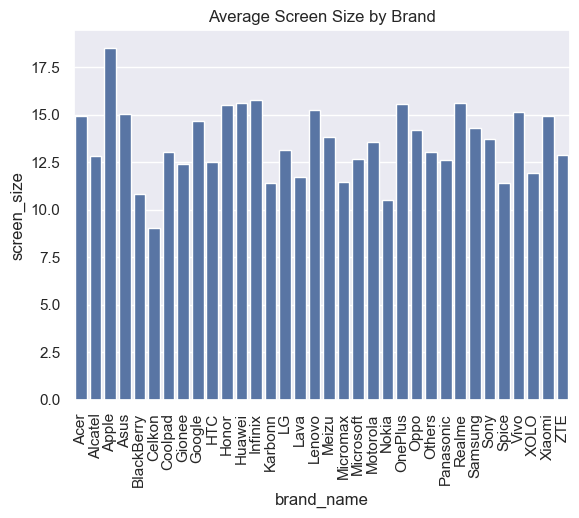

In [119]:
#Bar plot of average screen size by brand
df_brand_size = df1.groupby('brand_name')['screen_size'].mean().reset_index()

sns.barplot(data=df_brand_size, x='brand_name', y='screen_size')
plt.title('Average Screen Size by Brand')
plt.xticks(rotation=90)
plt.show()

**Observations**

Apple has the largest average screen size and Blackberry the smallest.  The variation seen is likely heavily influenced by which brands produce tablets.

### Brand v New Price

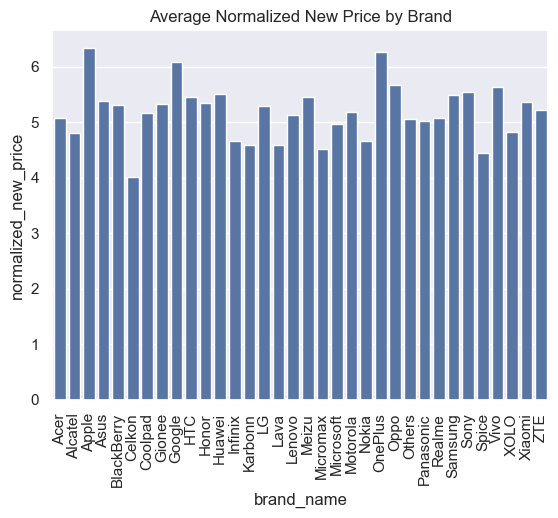

In [120]:
#Bar plot of average normalized new price by brand
df_brand_price = df1.groupby('brand_name')['normalized_new_price'].mean().reset_index()

sns.barplot(data=df_brand_price, x='brand_name', y='normalized_new_price')
plt.title('Average Normalized New Price by Brand')
plt.xticks(rotation=90)
plt.show()

**Observations**

Apple and OnePlus are the highest average price point for new devices

Celkon is the lowest average price point for new devices.

### Brand v Used Price

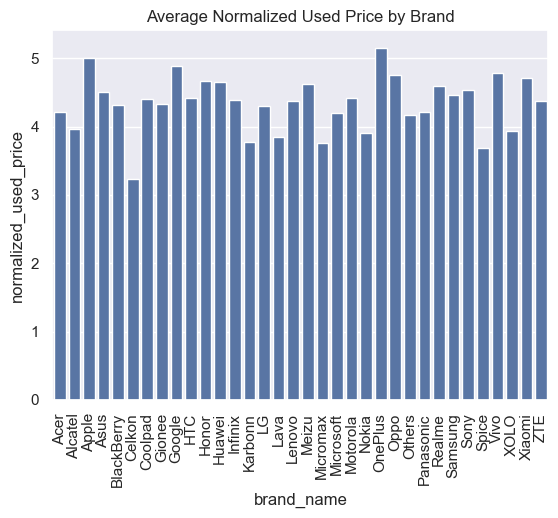

In [121]:
#Bar Plot of average normalized used price by brand
df_brand_used = df1.groupby('brand_name')['normalized_used_price'].mean().reset_index()

sns.barplot(data=df_brand_used, x='brand_name', y='normalized_used_price')
plt.title('Average Normalized Used Price by Brand')
plt.xticks(rotation=90)
plt.show()

**Observations**

We see similar trends in the used prices when compared with new.

Apple and OnePlus are again the highest average price points.  OnePlus appears to have held it's value a little better than Apple.

Celkon remains the lowest average price point among brands of used devices.

Finally, we haven't yet looked at any bivariate relationships with the 4g and 5g availability.  Since we are most concerned in our model with resale prices let's check out the impact of 4g and 5g availability on the normalized used price.

### 4g v Used Price

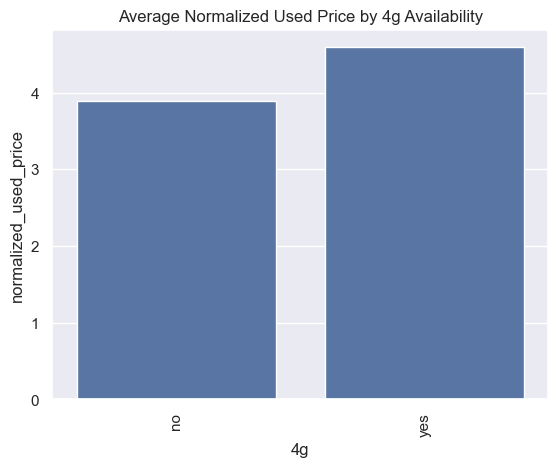

In [122]:
df_4g_used_price = df1.groupby('4g')['normalized_used_price'].mean().reset_index()
sns.barplot(df_4g_used_price, x='4g', y='normalized_used_price')
plt.title('Average Normalized Used Price by 4g Availability')
plt.xticks(rotation=90)
plt.show()

In [123]:
df_4g_used_price

,4g,normalized_used_price
0,no,3.896
1,yes,4.589


**Observations**

As expected, whether or not 4g is available on a device appears to have an impact on the resale value.

### 5g v Used Price

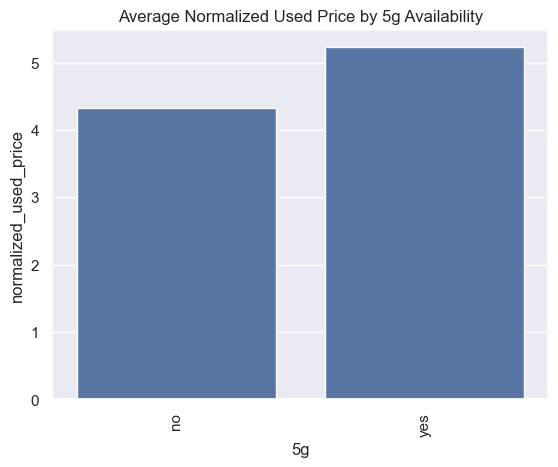

In [124]:
df_5g_used_price = df1.groupby('5g')['normalized_used_price'].mean().reset_index()
sns.barplot(df_5g_used_price, x='5g', y='normalized_used_price')
plt.title('Average Normalized Used Price by 5g Availability')
plt.xticks(rotation=90)
plt.show()

In [125]:
df_5g_used_price

,5g,normalized_used_price
0,no,4.325
1,yes,5.225


**Observations**

As with 4g, whether or not 5g is available on a device appears to have an impact on the resale value.

It is outside the scope of this project, but analysis could be done to identify the impact of value retention in the used market from having 4g, only or 4g and 5g.

**4g and 5g**

As a final sanity check let's see the relationship of devices with 4g, 5g, and both.

In [126]:
pd.crosstab(df1['4g'], df1['5g'])

5g,no,yes
4g,,
no,1119,0
yes,2183,152


**Observations**

As expected there all devices with 5g also have 4g, but not all devices with 4g have 5g.

### Remaining Project Questions

In [127]:
#Ram by Brand
df1.groupby('brand_name')['ram'].mean().sort_values(ascending = False)

brand_name
OnePlus      6.364
Oppo         4.961
Vivo         4.756
Huawei       4.655
Honor        4.603
Xiaomi       4.583
Google       4.533
Meizu        4.452
Samsung      4.199
Realme       4.195
Sony         4.070
Asus         4.049
ZTE          4.023
Microsoft    4.000
XOLO         4.000
HTC          4.000
Apple        4.000
Panasonic    4.000
Coolpad      3.955
Motorola     3.943
LG           3.937
Gionee       3.933
Acer         3.902
Lenovo       3.886
BlackBerry   3.830
Others       3.778
Spice        3.750
Micromax     3.679
Alcatel      3.407
Karbonn      3.353
Lava         3.278
Infinix      2.600
Nokia        2.330
Celkon       1.614
Name: ram, dtype: float64

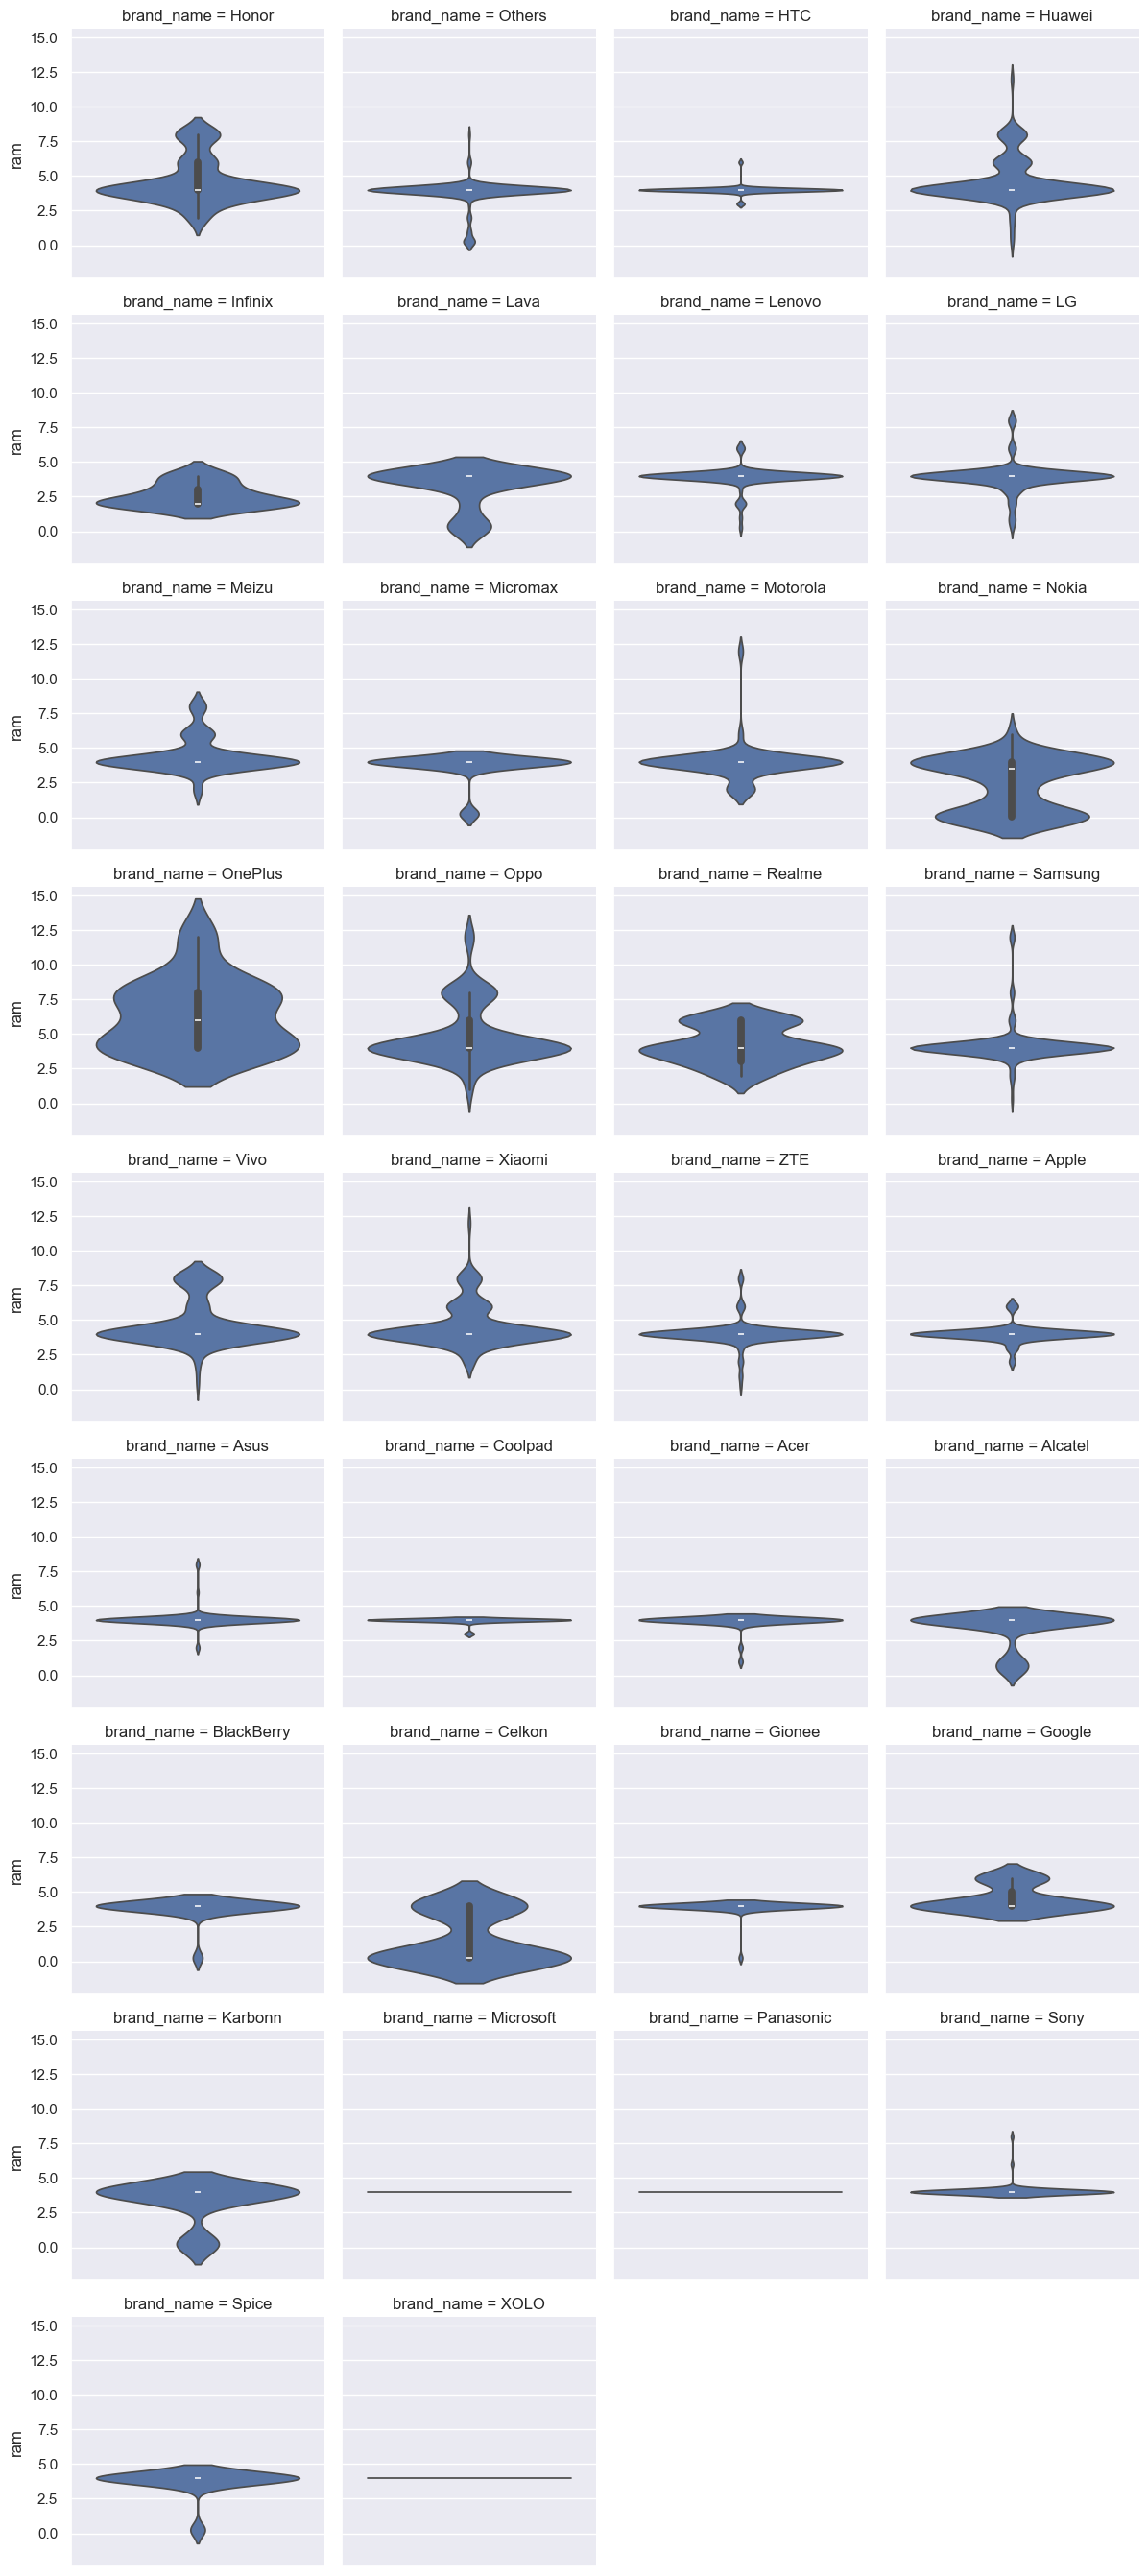

In [128]:
g = sns.FacetGrid(df1, col="brand_name", col_wrap=4, sharey=True)
g.map_dataframe(sns.violinplot, y="ram")

plt.show()

**Project Question Answered**

3.	The amount of RAM is important for the smooth functioning of a device. How does the amount of RAM vary with the brand?

While Ram varies within brands, OnePlue offers the highest mean RAM (6.364 GB) while Celkon offers the lowest mean RAM (1.614 GB)

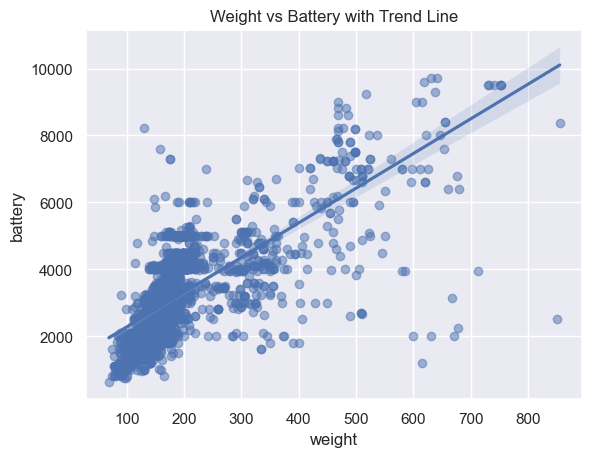

In [129]:
#Weight V Battery
sns.regplot(data = df1, x="weight", y="battery", scatter_kws={'alpha':0.5})
plt.title("Weight vs Battery with Trend Line")
plt.show()

**Project Question Answered**

4.	A large battery often increases a device's weight, making it feel uncomfortable in the hands. How does the weight vary for phones and tablets offering large batteries (more than 4500 mAh)?

As seen in the heatmap above, weight and battery are positively correlated (.7)

## Model Building - Linear Regression

### Data Preparation for Modeling

In [130]:
#Split the data into dependent and independent variables

#Set of independent variables
X = df1.drop(['normalized_used_price'], axis = 1)

#Dependent variable
y = df1['normalized_used_price']

#Check
#print(X.head())
#print(y.head())

In [131]:
#Create Dummy Variables for the object columns
X = pd.get_dummies(
    X,
    columns = X.select_dtypes(include=['object', 'category']).columns.tolist(),
    drop_first = True
)

#Check
#X.head()

In [132]:
#Add Constant Intercept Constant
X = sm.add_constant(X)

#Check
#print(X.head())

In [133]:
#Convert all variables to float type for modeling
X = X.astype(float)

#Check
X.head()

,const,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_new_price,yrs_past_release,brand_name_Alcatel,brand_name_Apple,brand_name_Asus,brand_name_BlackBerry,brand_name_Celkon,brand_name_Coolpad,brand_name_Gionee,brand_name_Google,brand_name_HTC,brand_name_Honor,brand_name_Huawei,brand_name_Infinix,brand_name_Karbonn,brand_name_LG,brand_name_Lava,brand_name_Lenovo,brand_name_Meizu,brand_name_Micromax,brand_name_Microsoft,brand_name_Motorola,brand_name_Nokia,brand_name_OnePlus,brand_name_Oppo,brand_name_Others,brand_name_Panasonic,brand_name_Realme,brand_name_Samsung,brand_name_Sony,brand_name_Spice,brand_name_Vivo,brand_name_XOLO,brand_name_Xiaomi,brand_name_ZTE,os_Others,os_Windows,os_iOS,4g_yes,5g_yes
0,1.000,14.500,13.000,5.000,64.000,3.000,3020.000,146.000,127.000,4.715,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
1,1.000,17.300,13.000,16.000,128.000,8.000,4300.000,213.000,325.000,5.519,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000
2,1.000,16.690,13.000,8.000,128.000,8.000,4200.000,213.000,162.000,5.885,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000
3,1.000,25.500,13.000,8.000,64.000,6.000,7250.000,480.000,345.000,5.631,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000
4,1.000,15.320,13.000,8.000,64.000,3.000,5000.000,185.000,293.000,4.948,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000


In [134]:
#Split training data into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=1)

#Test/Test set to 70/30
#Random state set to 1 for repeatability

In [135]:
#Check the split results
print("Training size =", X_train.shape[0])
print("Test size =", X_test.shape[0])

Training size = 2417
Test size = 1037


### Fit Model

In [136]:
#Fit Model
olsmodel = sm.OLS(y_train, X_train).fit()

#Print Summary of fit
print(olsmodel.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.845
Model:                               OLS   Adj. R-squared:                  0.842
Method:                    Least Squares   F-statistic:                     268.6
Date:                   Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                           09:50:59   Log-Likelihood:                 123.24
No. Observations:                   2417   AIC:                            -148.5
Df Residuals:                       2368   BIC:                             135.2
Df Model:                             48                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


**Interpreting Results**

1. **R-Squared** value indicates the  model can explain 84.5% of the variance in the dependent variable in the training data.
2. **Adjusted R-Squared** value of .842 indicates that the model is a strong fit after accounting for the number of predictors.
3. **Constant Coefficient** of 1.3288 represents the predicted value of the dependent variable when all predictors are zero, though this is not be meaningful as zero predictors would indicate no device to evaluate or sell.
4. **Coefficients of Predictor Variables**: All predictors variable coefficients are displayed above
5. **t-Statistic**:  normalized_new_price has the largest absolute t-statistic, indicating the strongest evidence that its coefficient is different from zero.  screen_size, main_camera_mp, and selfie_camera_mp also have large t-statistics.
6. **P>abs(t)**: Several variables have p-values that are effectively zero (very close to 0), indicating strong statistical evidence that their coefficients are not zero.

## Model Performance Check

In [137]:
#Defind Function to Display key model performance values

def model_performance(model, predictors, targets, label):
    
    # Predictions
    predictions = model.predict(predictors)
    
    # R-squared
    r2 = r2_score(targets, predictions)
    
    # Adjusted R-squared
    n = predictors.shape[0] #Get number of observations
    k = predictors.shape[1] #Get number of independent variables (predictors)
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
    
    # Error metrics
    rmse = np.sqrt(mean_squared_error(targets, predictions))
    mae = mean_absolute_error(targets, predictions)
    
    # MAPE (safe version)
    mape = np.mean(np.abs((targets - predictions) / targets)) * 100
    
    # Create DataFrame
    df_performance = pd.DataFrame(
        {
            "R-sq": r2,
            "Adj_R-sq": adj_r2,
            "RMSE": rmse,
            "MAE": mae,
            "MAPE": mape,
        },
        index=[0],
    )
    print(label)
    return df_performance

In [138]:
model_performance(olsmodel, X_train, y_train, 'Training Data')

Training Data


,R-sq,Adj_R-sq,RMSE,MAE,MAPE
0,0.845,0.842,0.230,0.180,4.330


In [139]:
model_performance(olsmodel, X_test, y_test, 'Test Data')

Test Data


,R-sq,Adj_R-sq,RMSE,MAE,MAPE
0,0.843,0.835,0.238,0.184,4.483


**Observations**

There is no evidence of overfitting or underfitting.

**R-Squared & Adj R-Squared**: 
The model explains about 84% of the variance in both training and test sets, and performance is very similar across them.

There is no meaningful drop from training to test.

Adjusted R-Squared is close to R-Squared, so the model is not overfitting

The model generalizes well.

**RMSE & MAE**

The prediction error increases only slightly on the test set, indicating stable predictive performance.

Small train-test gap indicates good generalization; errors are low and consistent

RMSE > MAE indicating mild sensitivity to larger errors

**MAPE**

On average, predictions are off by about 4–4.5%

Relatively accurate model

Slight degradation on test set

## Checking Linear Regression Assumptions

### TEST FOR MULTICOLLINEARITY

Testing for Multicollinearity using Variance Inflation Factor (VIF)

In [140]:
#Define Function to compute VIF
def compute_vif(predictors):
    vif_data = pd.DataFrame()
    vif_data['feature'] = predictors.columns

    vif_data['VIF'] = [
        variance_inflation_factor(predictors.values, i)
        for i in range(predictors.shape[1])
    ]

    return vif_data

In [141]:
vif1 = compute_vif(X)
vif1

,feature,VIF
0,const,218.577
1,screen_size,7.213
2,main_camera_mp,2.140
3,selfie_camera_mp,2.862
4,int_memory,1.296
5,ram,2.302
6,battery,4.281
7,weight,5.828
8,days_used,2.585
9,normalized_new_price,3.113


In [142]:
#Crosstab check Apple v. iOS
pd.crosstab(df['brand_name'] == 'Apple', df['os'] == 'iOS')

os,False,True
brand_name,,
False,3415,0
True,3,36


**Observations**

Constant has high VIF, but this is normal.

**VIF > 10**

os_iOS

brand_name_Apple

Brand name Apple and OS iOS are HIGHLY correlated.  However, we saw above that not all Apple devices were running on iOS.  Doing a quick crosstab check (cell above) we confirm that all iOS is running on Appple devices, but not all Apple devices are running iOS.  Additonally brand is likely very important for resale price here.  We will drop iOS OS as a feature.

**VIF > 5**

screen_size

weight

Screen Size and Weight are certainly linked, but represent different concepts so we will keep these.

brand_name_Huawei

brand_name_Others

brand_name_Samsung

Brand names are likely highly correlated with a number of features common to the brand.  However it doesn't make sense to drop only some brand names.

**Actions**

At the moment we are leaning toward dropping os_iOS, but let's check the impact of dropping each column with VIF >5 to check our instinct.

In [143]:
def treating_multicollinearity(predictors, target, high_vif_columns):
    """
    Evaluates impact of dropping high-VIF features on model performance.

    Parameters:
        predictors (pd.DataFrame): Feature matrix
        target (pd.Series): Target variable
        high_vif_columns (list): Columns to test removal one at a time

    Returns:
        pd.DataFrame: Impact on Adj. R-squared and RMSE
    """

    results = []

    for col in high_vif_columns:

        # drop single column safely (exact match)
        X_temp = predictors.drop(columns=[col], errors='ignore')

        # fit model
        model = sm.OLS(target, X_temp).fit()

        # store results
        results.append({
            "col": col,
            "adj_r2": model.rsquared_adj,
            "rmse": np.sqrt(model.mse_resid)
        })

    return (
        pd.DataFrame(results)
        .sort_values("adj_r2", ascending=False)
        .reset_index(drop=True)
    )

In [144]:
#List columns > 5 VIF
col_list = vif1.loc[(vif1['VIF'] > 5) & (vif1['feature'] != 'const'), 'feature'].tolist()

#Run above function to compare results of dropping each column
res1 = treating_multicollinearity(X_train, y_train, col_list)
res1

,col,adj_r2,rmse
0,brand_name_Apple,0.842,0.232
1,brand_name_Huawei,0.842,0.232
2,brand_name_Others,0.842,0.232
3,os_iOS,0.842,0.232
4,brand_name_Samsung,0.842,0.232
5,screen_size,0.838,0.235
6,weight,0.838,0.235


**Observations**
This confirms our above conclusion that os_iOS should be the first column dropped to correct collinearity.

Variables screen_size and weight should not be removed, as their exclusion leads to a noticeable decrease in adjusted R-Squared.

Among the remaining high-VIF variables, dropping any of them results in negligible change in model performance. This suggests redundancy among these predictors.

Based on domain understanding, os_iOS is largely redundant with brand_name_Apple, as iOS runs exclusively on Apple products in this dataset resulting in perfect multicollinearity. Therefore if any predictor is to be removed, removing os_iOS is preferred, as it reduces multicollinearity without sacrificing interpretability or predictive performance.

In [145]:
#Create new train and test set with selected column dropped
col_to_drop = 'os_iOS'
X_train2 = X_train.drop(columns=[col_to_drop])
X_test2 = X_test.drop(columns=[col_to_drop])

#Check
#X_train2.head()

In [146]:
# Compute new VIF
vif2 = compute_vif(X_train2)
print("New VIF after dropping ", col_to_drop)
vif2

New VIF after dropping  os_iOS


,feature,VIF
0,const,227.511
1,screen_size,7.579
2,main_camera_mp,2.132
3,selfie_camera_mp,2.802
4,int_memory,1.362
5,ram,2.278
6,battery,4.176
7,weight,6.440
8,days_used,2.669
9,normalized_new_price,3.128


**Observations**

Constant has high VIF, but this is normal.

**VIF > 10**

There are no longer any predictors with VIF>10

**VIF > 5**

screen_size (7.579)

weight (6.440)

brand_name_Others (9.711)

brand_name_Samsung (7.539)

brand_name_Huawei (5.986)

In [147]:
#List columns > 5 VIF
col_list2 = vif2.loc[(vif2['VIF'] > 5) & (vif2['feature'] != 'const'), 'feature'].tolist()

#Run above function to compare results of dropping each column
res2 = treating_multicollinearity(X_train2, y_train, col_list2)
res2

,col,adj_r2,rmse
0,brand_name_Huawei,0.842,0.232
1,brand_name_Others,0.842,0.232
2,brand_name_Samsung,0.842,0.232
3,screen_size,0.838,0.235
4,weight,0.838,0.235


**Observations**

After removing os_iOS, multicollinearity was reduced significantly, with no variables exceeding a VIF of 10. The remaining predictors with VIF > 5 primarily consist of brand-related dummy variables and correlated physical characteristics (screen size and weight).

However, these variables do not exhibit the same level of structural redundancy observed earlier (e.g., os_iOS vs brand_name_Apple). Furthermore, removing them does not lead to any meaningful improvement in adjusted R-squared or RMSE, and in some cases slightly degrades model performance.

Dropping screen_size or weight each reduces Adj R² from 0.842 to 0.838 — a meaningful cost. Given these are physically meaningful features rather than structurally redundant ones, retaining them is justified.

Let's see what happens when we treat P-Values and we can circle back to VIF if needed.

In [148]:
#Refit and inspect the new model without os_iOS column
olsmodel2 = sm.OLS(y_train, X_train2).fit()
print(olsmodel2.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.845
Model:                               OLS   Adj. R-squared:                  0.842
Method:                    Least Squares   F-statistic:                     274.4
Date:                   Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                           09:51:00   Log-Likelihood:                 123.17
No. Observations:                   2417   AIC:                            -150.3
Df Residuals:                       2369   BIC:                             127.6
Df Model:                             47                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


In [149]:
model_performance(olsmodel2, X_train2, y_train, 'Training Data after VIF')

Training Data after VIF


,R-sq,Adj_R-sq,RMSE,MAE,MAPE
0,0.845,0.842,0.230,0.180,4.330


In [150]:
model_performance(olsmodel2, X_test2, y_test, 'Test Data after VIF')

Test Data after VIF


,R-sq,Adj_R-sq,RMSE,MAE,MAPE
0,0.843,0.835,0.238,0.184,4.484


**Observations**

Almost no significant change in model performance noted from VIF actions above.

### High p-value Variables

In [151]:
#Eliminate P-Values >.05 starting with largest
def backward_elimination(Predictors, Target, alpha=0.05):
    Predictors = Predictors.copy()
    removed_features = [] #List features that have been removed
    
    while True:
        model = sm.OLS(Target, Predictors).fit()
        p_values = model.pvalues.drop('const', errors='ignore')
        
        max_p = p_values.max()
        
        if max_p > alpha:
            remove_feature = p_values.idxmax()
            Predictors = Predictors.drop(columns=[remove_feature])
            removed_features.append(remove_feature)
        else:
            break
    
    return model, Predictors, removed_features

In [152]:
#Run p-value elimination function and list dropped variables
olsmodel3, X_train3, dropped = backward_elimination(X_train2, y_train)
dropped

['brand_name_ZTE',
 'brand_name_Vivo',
 'brand_name_Huawei',
 'brand_name_Others',
 'brand_name_Spice',
 'brand_name_HTC',
 'brand_name_LG',
 'brand_name_Google',
 'os_Windows',
 'brand_name_BlackBerry',
 'brand_name_Meizu',
 'brand_name_Motorola',
 'brand_name_XOLO',
 'brand_name_Celkon',
 'brand_name_Coolpad',
 'brand_name_Lava',
 'brand_name_Alcatel',
 'brand_name_Asus',
 'brand_name_Oppo',
 'brand_name_Honor',
 'brand_name_Gionee',
 'brand_name_Micromax',
 'days_used',
 'int_memory',
 '5g_yes',
 'brand_name_Microsoft',
 'brand_name_Apple',
 'brand_name_Panasonic',
 'brand_name_Sony',
 'brand_name_Samsung',
 'brand_name_Infinix',
 'battery',
 'brand_name_Karbonn',
 'brand_name_OnePlus']

In [153]:
#Update X_test to match X_train by dropping same columns
X_test3 = X_test2.drop(columns=dropped)

In [154]:
#Check New Model Summary
print(olsmodel3.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.842
Model:                               OLS   Adj. R-squared:                  0.841
Method:                    Least Squares   F-statistic:                     986.7
Date:                   Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                           09:51:00   Log-Likelihood:                 103.26
No. Observations:                   2417   AIC:                            -178.5
Df Residuals:                       2403   BIC:                            -97.45
Df Model:                             13                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

In [155]:
model_performance(olsmodel3, X_train3, y_train, 'Training Data after high p-value elimination')

Training Data after high p-value elimination


,R-sq,Adj_R-sq,RMSE,MAE,MAPE
0,0.842,0.841,0.232,0.182,4.362


In [156]:
model_performance(olsmodel3, X_test3, y_test, 'Test Data after high p-value elimination')

Test Data after high p-value elimination


,R-sq,Adj_R-sq,RMSE,MAE,MAPE
0,0.845,0.843,0.237,0.183,4.445


**Observations**

We see slight degredation in training data performance, but slight improvement in testing data performance.

As expected some of the columns on our VIF > 5 list were removed in P-value treatment.  Let's take a look at VIF now.

In [157]:
# Compute new VIF
vif3 = compute_vif(X_train3)
print("New VIF after dropping high p-values")
vif3

New VIF after dropping high p-values


,feature,VIF
0,const,119.889
1,screen_size,6.760
2,main_camera_mp,1.799
3,selfie_camera_mp,2.488
4,ram,1.707
5,weight,5.463
6,normalized_new_price,2.405
7,yrs_past_release,2.966
8,brand_name_Lenovo,1.025
9,brand_name_Nokia,1.210


In [158]:
#List columns > 5 VIF
col_list3 = vif3.loc[(vif3['VIF'] > 5) & (vif3['feature'] != 'const'), 'feature'].tolist()

#Compare results of dropping each column on training data
res3 = treating_multicollinearity(X_train3, y_train, col_list3)
res3

,col,adj_r2,rmse
0,weight,0.838,0.235
1,screen_size,0.838,0.235


In [159]:
#Compare results of dropping each column on test data
res3 = treating_multicollinearity(X_test3, y_test, col_list3)
res3

,col,adj_r2,rmse
0,weight,0.842,0.239
1,screen_size,0.840,0.241


**Observations**

We are left with weight and screen_size having a VIF > 5 still.  However, removing either one of these results in model performance degradation on both the training and test set.  Therefore we will leave these columns in place rather than dropping them simply because the VIF > 5.

### TEST FOR LINEARITY AND INDEPENDENCE

In [160]:
# Create DF of Actual, Fitted, and Residual Values
df_pred = pd.DataFrame()

df_pred["Actual"] = y_train
df_pred["Predicted"] = olsmodel3.fittedvalues
df_pred["Residual"] = olsmodel3.resid

df_pred.head()

,Actual,Predicted,Residual
3026,4.087,3.856,0.232
1525,4.448,4.630,-0.182
1128,4.315,4.281,0.034
3003,4.282,4.225,0.057
2907,4.456,4.471,-0.014


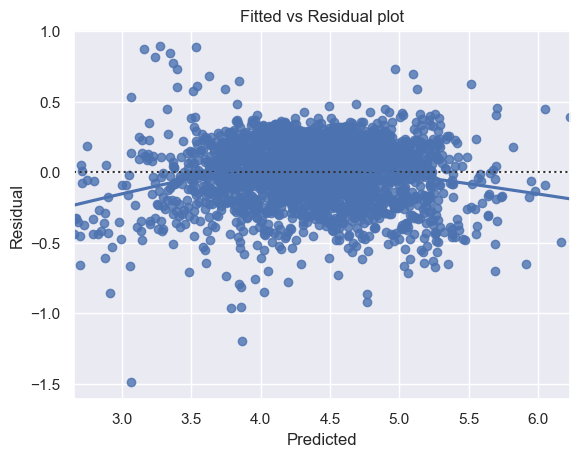

In [161]:
# Plot Predicted v. Residual
sns.residplot(data=df_pred, x='Predicted', y='Residual', lowess=True)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Fitted vs Residual plot")
plt.show()

**Observations**

The residuals vs fitted values plot shows a slight inverted U-shaped pattern in the LOWESS curve, indicating a mild degree of non-linearity in the relationship between the predictors and the target variable. Specifically, residuals tend to be slightly negative at lower and higher fitted values and slightly positive in the mid-range, suggesting the model may be overpredicting at the extremes and underpredicting in the middle.

However, the pattern is not strongly pronounced, and the residuals remain largely scattered around zero without clear systematic structure. Therefore, the linearity assumption appears to be reasonably satisfied for this model.

Independence is assumed as the dataset does not represent time-series or ordered observations.

### TEST FOR NORMALITY

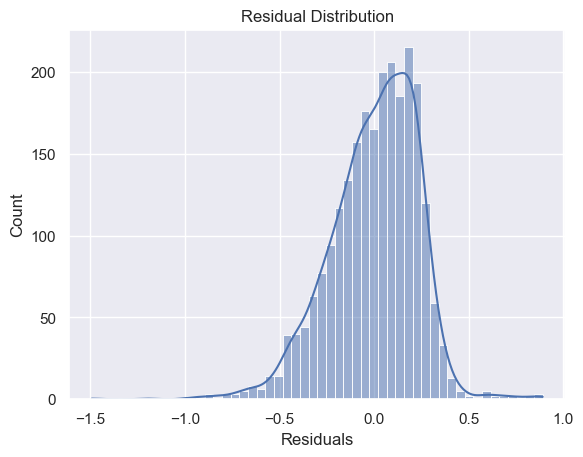

In [162]:
#Histplot of residuals
sns.histplot(olsmodel3.resid, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()

In [163]:
describe_distribution(df_pred, 'Residual')

Lower Outlier Fence = -0.6014445480894433
Upper Outlier Fence = 0.6364902438720159
Outlier count: 44
Skewness:  -0.6188097534412692
The distribution is moderately skewed to the left.


count   2417.000
mean       0.000
std        0.232
min       -1.492
25%       -0.137
50%        0.029
75%        0.172
max        0.891
Name: Residual, dtype: float64

**Observations**

In the histplot we see what appears to be a generally normal distribution around 0 with light tails and a moderate left skew.

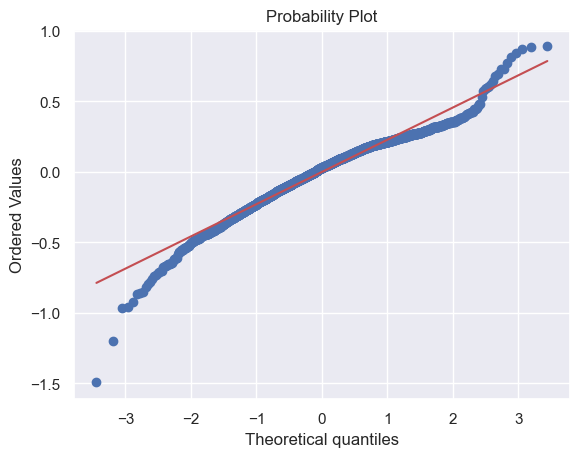

In [164]:
#Q-Q
stats.probplot(olsmodel3.resid, dist="norm", plot=pylab)
plt.show()

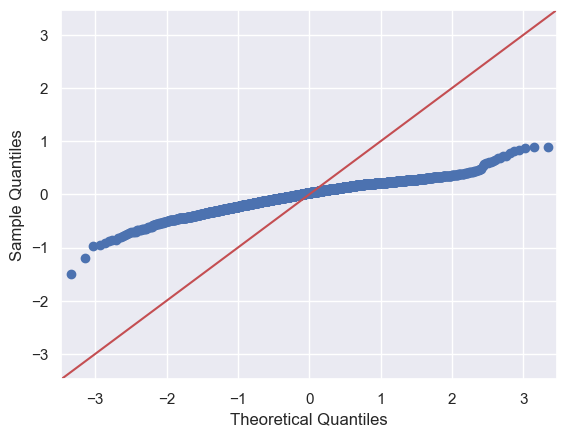

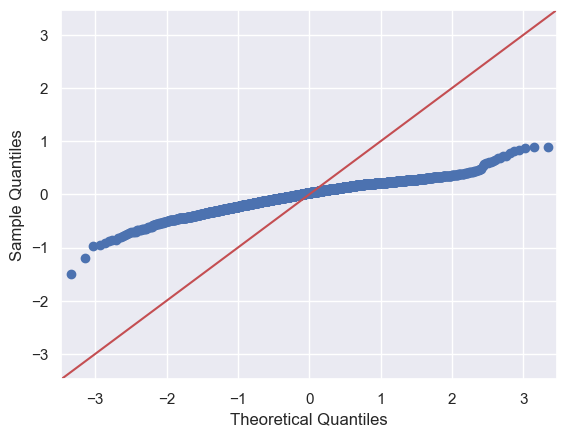

In [165]:
sm.qqplot(olsmodel3.resid, line='45')

In [166]:
#Shapiro-Wilks Test
stat, p_value = stats.shapiro(olsmodel3.resid)
print("Shapiro-Wilk p-value:", p_value)

Shapiro-Wilk p-value: 2.5917239254773236e-22


**Observations**

The distribution of residuals appears generally normal around 0 with light tails and a moderate left skew (skewness ≈ -0.62), indicating moderate asymmetry. The Q-Q plot demonstrates that the residuals largely follow a straight-line pattern, with minor deviations observed in the tails. The Shapiro-Wilk test yields a very small p-value (< 0.05), suggesting a statistical departure from normality. However, given the visual evidence and the known sensitivity of the Shapiro-Wilk test to large sample sizes, the deviation from normality is not considered substantial. Therefore, the normality assumption is reasonably satisfied.

### TEST FOR HOMOSCEDASTICITY

In [167]:
gq_test = het_goldfeldquandt(olsmodel3.resid, X_train3)

print("F-statistic:", gq_test[0])
print("p-value:", gq_test[1])

F-statistic: 1.0469845776444135
p-value: 0.21381829849718675


**Observations**

The Goldfeld–Quandt test yields a p-value greater than 0.05, indicating no significant evidence of heteroscedasticity. This suggests that the variance of residuals remains approximately constant across fitted values, and the assumption of homoscedasticity is satisfied.

## Final Model

In [168]:
#Storing OLS model 3 as our final model and examining it in detail.
model_final = olsmodel3
print(model_final.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.842
Model:                               OLS   Adj. R-squared:                  0.841
Method:                    Least Squares   F-statistic:                     986.7
Date:                   Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                           09:51:02   Log-Likelihood:                 103.26
No. Observations:                   2417   AIC:                            -178.5
Df Residuals:                       2403   BIC:                            -97.45
Df Model:                             13                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

In [169]:
#Check training performance
model_performance(model_final, X_train3, y_train, 'Final Model Training Performance')

Final Model Training Performance


,R-sq,Adj_R-sq,RMSE,MAE,MAPE
0,0.842,0.841,0.232,0.182,4.362


In [170]:
#Check test performance
model_performance(model_final, X_test3, y_test, 'Final Model Test Performance')

Final Model Test Performance


,R-sq,Adj_R-sq,RMSE,MAE,MAPE
0,0.845,0.843,0.237,0.183,4.445


**Observations**

Our final model performs well on both training and test data with little variance in performance.  

Residuals appear to be a generally normal in distribution around 0 with light tails and a moderate left skew. The Shapiro-Wilk test yields a very small p-value (< 0.05), indicating moderate asymmetry.  

Homoscedasticity is satisfied. 

Durbin-Watson = 1.908, which is very close to 2.0 (the ideal value) indicating no autocorrelation and supporting the independence of errors assumption.

Condition numbers above 1000 (2380 in this case) warrant attention, but given we have already treated VIF and this is primarily driven by scale differences between variables (battery in thousands vs binary dummies), it doesn't indicate a structural problem in this case.

## Actionable Insights and Recommendations

### Summary Of Insights

**Preprocessing**

1. There are some questionably low values in the main Camera data, but not sufficiently low to determine with confidence that they were recorded in error.

2. There are many legitimate high outliers in the data for both main and selfie cameras.

3. The quality of this data is questionable in several areas:

- Pulling the devices with >500 GB internal memory, we see quite a few with large memory and very small screens which sets off alarm bells. It is very possible that either the screen size or the internal memory values are incorrect.  It is also possible that some screen sizes were input in inches whereas the above information states measurements are in CM. 

- It is possible that some data did not fit the format of this table (ie devices with 2 screens).  Example: (from a Google search for one of these devices) "The ASUS ZenBook Pro 14 Duo OLED (UX8402) (such as model UX8402ZA-DB76T) fits this description, *featuring a main 14.5-inch screen and a 12.7-inch* 2.8K 120Hz *secondary touchscreen* (ScreenPad Plus). It includes 1TB M.2 NVMe PCIe 4.0 SSD storage, 32GB RAM, and an Intel Core i9 processor."

- One device was listed with a 500mAh battery which is suspiciously low.  A Google search turned up an exact match except with a 5,000mAh battery.  This indicates that there is very probably at least one, and considering the above more than one data entry error in this set.

**Model**

1. *Initial Data*: Started with a set of 3454 observations across 15 Columns.

2. *Initial Model*: This led to an initial model with 48 independent variables.

3. *Final Model*: After treating for multicollinearity and eliminating high p-value variables the resulting final model has 13 independent variables.

4. *Model Performance*: Our final model performs well on both training and test data with little variance in performance (Adj. R-Squared of .841 training and .843 testing). The distribution of residuals appears generally normal around 0 with light tails and a moderate left skew (skewness ≈ -0.62), indicating moderate asymmetry. The Q-Q plot demonstrates that the residuals largely follow a straight-line pattern, with minor deviations observed in the tails. The Shapiro-Wilk test yields a very small p-value (< 0.05), suggesting a statistical departure from normality. However, given the visual evidence and the known sensitivity of the Shapiro-Wilk test to large sample sizes, the deviation from normality is not considered substantial. Therefore, the normality assumption is reasonably satisfied. Homoscedasticity is satisfied suggesting that the variance of residuals remains approximately constant across fitted values.

- Able to explain > 84% of the variance in the dependent variable in both training and test data.
- Can be reliably used to estimate resale prices within ~4-5% error.

### Recommendations

1. Prioritize procurement of:
- Devices with higher prices when new: normalized_new_price (coef 0.42) is by far the strongest predictor of normalized_used_price.
- Devices with larger screen size (coef .0238 per cm of screen size)
- Higher resolution main camera (coef .0205 per MP)
- 4g Capable Devices (coef 0.043)
- Higher resolution selfie camera (coef .014 per MP)
- Devices with more RAM (coef .0209 per GB)
- Low yrs_past_release (coef -0.021 per year): Negatively correlated with used price.
- Brand Names: Realme, Xiaomi, Nokia, and Lenovo

2. Deprioritize focus on days used and battery.  Surprisingly, the number of days a device has been used and its battery don't significantly predict its resale price once other factors are controlled for.

3. Implement current model for pricing guidance and predictions.  While the below recommendations are centered around improving data quality and model performance, the current model is a strong fit, performs well and is able to explain > 84% of the variance in the dependent variable in both training and test data.

4. Invest in potential future model improvements:

- Verify quality of data collection.  Request fresh data if possible.  If unable to obtain fresh data or verify quality, eliminate devices with small screens and very high memory.  Re-run modeling, and compare outcomes.
- Split data into devices and phones and create a model for each category.
- Consider imputing using total column mean and median values (versus imputing on like device groups as done above) and compare final model performance to further validate current approach.
- Consider dropping Apple devices that are running on anything other than iOS from the data set as these are either recorded in error or such a small subset that the data is unlikely to be reliable.  Compare performance to current model.

___